(C) 2025 Gerold Baier, University College London

# Two Nonlinear Population Oscillator with Perturbation
## Model

The two populations' temporal dynamics (change of state) is described by two first-order nonlinear differential equations:

$$ \frac{dEx_1}{dt}      = (h_{ex}      - Ex_1    - c_2*sigmoid(In_1) + c_{EE}*sigmoid(Ex_1)  + pert)*\tau_{ex}$$
$$ \frac{dIn_1}{dt} \,\, = (h_{in} \,\, - In_1 \, - c_4*sigmoid(In_1) + c_{EI}*sigmoid(Ex_1))*\tau_{in}$$


$Ex_i$ and $In_i$ are variables that change with time $t$ and represent the excitatory and inhibitory population, respectively.

$h_{ex}$ and $h_{in}$ are constant inputs to the populations. 

$c_2$ and $c_4$ are model parameters representing internal inhibitory coupling. 

$\tau_{ex}$ and $\tau_{in}$ are the poulation time constants.

$c_{EE}$ and $c_{EI}$ are self- and between population excitatory coupling parameters.

_pert_ represents external perturbation.

Function _sigmoid_ is a continuous step function, conmputationally implemented as tangens hyperbolicus.


In [1]:
from scipy.integrate import solve_ivp

import sk_dsp_comm.sigsys as ss

from numpy import tanh, mod, linspace, around, zeros, mod, asarray
from numpy import sin, pi, var, ndarray, flip, arange, sign

from numpy.random import default_rng, seed

from matplotlib.pyplot import subplots


from scipy.signal import find_peaks

from itertools import product

from models import one_oscillator


# Functions

In [2]:

def plot_bifdiagram(results_min_f, results_max_f, 
                    par_set):
    
    N = len(results_min_f)

    fig, ax = subplots(nrows=1, figsize=(5, 4))

    index = 'Ex'
    
    for xe, ye in zip(par_set, results_max_f[index]):

        if not isinstance(ye, ndarray):
            ax.scatter(xe, ye, c='r', s=6, marker='D')
        else:
            ax.scatter([xe] * len(ye), ye, s=3, c='k', marker='D')

    for xe, ye in zip(par_set, results_min_f[index]):

        if not isinstance(ye, ndarray):
            ax.scatter(xe, ye, c='r', s=6, marker='d')
        else:
            ax.scatter([xe] * len(ye), ye, s=3, c='gray', marker='d')


    ax.set_xticks(linspace(par_set[0], par_set[-1], 5));
    ax.set_xticklabels(around(linspace(par_set[0], par_set[-1], 5), 2), fontsize=16);

    ax.set_ylabel('EX', fontsize=14)

    y_min, y_max = ax.get_ylim()

    ax.set_ylim(y_min, y_max)
    ax.set_yticks(linspace(y_min, y_max, 3));
    ax.set_yticklabels(around(linspace(y_min, y_max, 3),2), fontsize=14);
    
    ax.set_xlabel('Parameter', fontsize=16)


    fig.tight_layout()
    
    return fig, ax

# Time Series

h_ex_0 = -6.9, h_in_0 = -4.0, frac_E, frac_I = 0.25, 0.00 

h_ex_0 = -6.95, h_in_0 = -4.0, frac_E, frac_I = 0.2, 0.00 

h_ex_0 = -6.95, h_in_0 = -4.0, frac_E, frac_I = 0.15, 0.00 

h_ex_0 = -7.0,  h_in_0 = -4.0, frac_E, frac_I = 0.2, 0.10

End of run: [ -2.09 -13.65]



NameError: name 'frac_E' is not defined

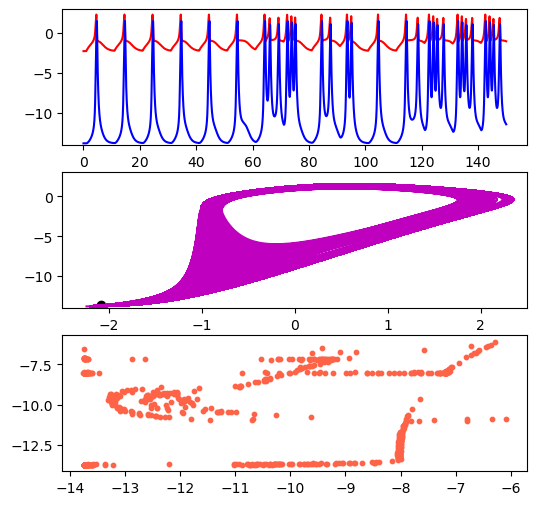

In [3]:
# Input parameter
h_ex_0 = -7.35
h_in_0 = -4.0

# Oscillator parameters
pars = (1, 2.5, 10, 0, 5, 10) # Homoclinic
# pars = (1, 1.5, 10, 0, 5, 10) # SNIC
# t_ex, t_in, c2, c4, cc_EE, cc_EI


# Initial conditions
SEED = 8888
rng  = default_rng(SEED)
# y_ini = rng.uniform(size=2)
y_ini = [ -2.24, -13.77]

# Time array
time_stop = 5000
sr        = 1000
time      = linspace(start=0, stop=time_stop, num=time_stop*sr)

rows = time.size

pulse_wid = 4.
pulse_amp = 0.8
pulse_per = 10

pert = h_ex_0 + pulse_amp*ss.rect(mod(time, pulse_per)-(pulse_per)/2+pulse_wid/2, pulse_wid)


# Simulation
solution = solve_ivp(fun=one_oscillator, t_span=(0, time_stop), y0=y_ini, 
              args=(h_in_0, pars, sr, time_stop, pert), 
              t_eval=time, method='BDF', max_step=0.1)


t, y_pert = solution.t, solution.y.T

# Resetting of initial conditions
y_ini = y_pert[-1, :]

# Show final values of all variables
print('End of run:', around(y_pert[-1,:],2))
print('')




start, end = 0, 150000

fig, ax = subplots(ncols=1, nrows=3, figsize=(6, 6))

ax[0].plot(time[start:end], y_pert[start:end,0], color='r');
# ax[0, 1].plot(time[start:end], y_pert[start:end,2], color='r');
ax[0].plot(time[start:end], y_pert[start:end,1], color='b');
# ax[0, 1].plot(time[start:end], y_pert[start:end,3], color='b');

ax[1].plot(y_pert[:,0], y_pert[:,1], color='m');
ax[1].scatter(y_pert[-1,0], y_pert[-1,1], color='k')

series = y_pert[y_pert.shape[0]//3:, 0]

e_max_inds = find_peaks(series, distance=100)
e_maxs     = series[e_max_inds[0]]

e_min_inds = find_peaks(-series, distance=100)
e_mins     = series[e_min_inds[0]]

series = y_pert[y_pert.shape[0]//3:, 1]

i_max_inds = find_peaks(series, distance=100)
i_maxs     = series[i_max_inds[0]]

i_min_inds = find_peaks(-series, distance=100)
i_mins     = series[i_min_inds[0]]

ax[2].scatter(i_mins[1:], i_mins[:-1], c='tomato', s=10);


# ax[0, 0].set_title('Comp 1')
# ax[0, 1].set_title('Comp 2')
# ax[0, 2].set_title('C1 vs C2')

# ax[0, 0].set_xlabel('Time')
# ax[0, 0].set_ylabel('Ex 1')
# ax[1, 0].set_xlabel('Ex 1')
# ax[1, 0].set_ylabel('In 1')
# ax[0, 1].set_xlabel('Time')
# ax[0, 1].set_ylabel('Ex 2')
# ax[1, 1].set_xlabel('Ex 2')
# ax[1, 1].set_ylabel('In 2')

# ax[0, 2].set_xlabel('Ex 1')
# ax[0, 2].set_ylabel('Ex 2')
# ax[1, 2].set_xlabel('In 1')
# ax[1, 2].set_ylabel('In 2')


# ax[0, 0].set_ylim(-15, 5)
# ax[0, 0].vlines(100-pulse_wid, -15, 5, color='gray')
# ax[0, 0].vlines(100, -15, 5, color='gray')
# ax[0, 0].fill_between([100-pulse_wid, 100], 0, 1, color='green', alpha=0.3, transform=ax[0, 0].get_xaxis_transform())

# ax[0, 1].set_ylim(-15, 5)
# ax[0, 1].vlines(100-pulse_wid, -15, 5, color='gray')
# ax[0, 1].vlines(100, -15, 5, color='gray')
# ax[0, 1].fill_between([100-pulse_wid, 100], 0, 1, color='green', alpha=0.3, transform=ax[0, 1].get_xaxis_transform())

ax[0].set_ylim(-14, 3)
ax[1].set_ylim(-14, 3)
ax[1].set_xlim(-2.5, 2.5)


# ax[2, 0].plot(time[start:end], y_pert[start:end,0], color='r');
# ax[2, 0].hlines(0, start//sr, end//sr, linestyle='--', color='k')
# ax[2, 0].set_title('Ex Diff')
# ax[2, 0].fill_between([100-pulse_wid, 100], 0, 1, color='green', alpha=0.3, transform=ax[2, 0].get_xaxis_transform())

# ax[2, 1].plot(time[start:end], y_pert[start:end,1]-y_pert[start:end,3], color='b');
# ax[2, 1].hlines(0, start//sr, end//sr, linestyle='--', color='k')
# ax[2, 1].set_title('In Diff')
# ax[2, 1].fill_between([100-pulse_wid, 100], 0, 1, color='green', alpha=0.3, transform=ax[2, 1].get_xaxis_transform())

# ax[2, 2].plot(y_pert[start:end,0]-y_pert[start:end,2], y_pert[start:end,1]-y_pert[start:end,3], color='m');
# ax[2, 2].scatter(y_pert[-1,0]    -y_pert[-1,2],        y_pert[-1,1]       -y_pert[-1,3], color='k')
# ax[2, 2].set_title('Ex Diff vs. In Diff')

    
# fig.suptitle(f'E-E: {frac_E} , E-I: {frac_I}')
    
fig.tight_layout()

(5000000, 2)

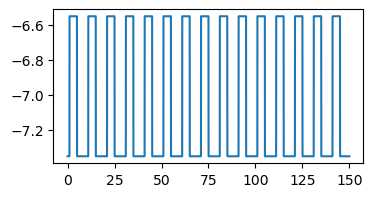

In [4]:
fig, ax = subplots(figsize=(4, 2))

ax.plot(time[:end], pert[:end])

y_pert.shape

# Poincaré Analysis of bifurcations DeepSeek

In [5]:
# import numpy as np
# from scipy.integrate import solve_ivp
# import sk_dsp_comm.sigsys as ss
# import matplotlib.pyplot as plt
# from numpy import tanh, mod, linspace, zeros, arange
# from scipy.signal import find_peaks
# import warnings
# warnings.filterwarnings('ignore')

# # Model functions (keeping your original functions)
# def sigmoid(u):
#     return np.tanh(u)

# def one_oscillator(t, y, h_in, pars, sr, time_stop, pert):
#     tau_ex, tau_in, c2, c4, c_EE, c_EI = pars
#     time_index = int(t*sr)
    
#     if time_index >= time_stop*sr:
#         dydt = np.zeros(2)
#         return dydt
#     else:
#         dydt = (
#             (pert[time_index] - y[0] - c2*sigmoid(y[1]) + c_EE*sigmoid(y[0]))*tau_ex,
#             (h_in             - y[1] - c4*sigmoid(y[1]) + c_EI*sigmoid(y[0]))*tau_in
#         )
#     return dydt

# # Parameters (from your code)
# h_ex_0 = -7.35
# h_in_0 = -4.0
# pars = (1, 2.5, 10, 0, 5, 10)
# y_ini = [-2.24, -13.77]
# time_stop = 150
# sr = 1000
# pulse_wid = 4.
# pulse_per = 10

# # Bifurcation analysis implementation
# def compute_poincare_map(pulse_amp, transient_periods=10, num_periods=1):
#     """Compute Poincaré map for given pulse amplitude"""
#     # Create time array and perturbation
#     time = linspace(start=0, stop=time_stop, num=time_stop*sr)
#     pert = h_ex_0 + pulse_amp*ss.rect(mod(time, pulse_per) - (pulse_per)/2 + pulse_wid/2, pulse_wid)
    
#     # Integrate with transient
#     sol = solve_ivp(fun=one_oscillator, t_span=(0, time_stop), y0=y_ini,
#                     args=(h_in_0, pars, sr, time_stop, pert),
#                     t_eval=time, method='BDF', max_step=0.1, rtol=1e-8, atol=1e-10)
    
#     # Extract solution after transient
#     t_vals = sol.t
#     y_vals = sol.y.T
    
#     # Skip initial transient (first 10 periods)
#     transient_time = transient_periods * pulse_per
#     mask = t_vals >= transient_time
#     t_vals = t_vals[mask]
#     y_vals = y_vals[mask]
    
#     # Sample at Poincaré section (start of each pulse period)
#     poincare_points = []
#     for period_start in np.arange(transient_time, time_stop, pulse_per):
#         idx = np.argmin(np.abs(t_vals - period_start))
#         if idx < len(y_vals):
#             poincare_points.append(y_vals[idx])
    
#     return np.array(poincare_points)

# def compute_monodromy_matrix(pulse_amp, epsilon=1e-6):
#     """Compute monodromy matrix (linearized Poincaré map) via finite differences"""
#     # Find periodic point (or approximate it)
#     poincare_pts = compute_poincare_map(pulse_amp, transient_periods=15, num_periods=5)
    
#     if len(poincare_pts) < 2:
#         return np.eye(2), np.array([1, 1]), None
    
#     # Use last point as approximate periodic point
#     x0 = poincare_pts[-1]
    
#     # Finite differences to compute Jacobian of Poincaré map
#     Φ = np.zeros((2, 2))
    
#     # Define function that maps state through one period
#     def map_through_one_period(state):
#         # Create time array for one period
#         time_period = linspace(0, pulse_per, int(pulse_per*sr))
#         pert_local = h_ex_0 + pulse_amp*ss.rect(mod(time_period, pulse_per) - 
#                                                 (pulse_per)/2 + pulse_wid/2, pulse_wid)
        
#         # Extend perturbation to cover integration
#         pert_full = np.concatenate([pert_local] * 3)  # 3 periods to be safe
        
#         # Integrate one period from given initial state
#         sol = solve_ivp(fun=one_oscillator, 
#                        t_span=(0, pulse_per), 
#                        y0=state,
#                        args=(h_in_0, pars, sr, pulse_per, pert_local),
#                        method='BDF', max_step=0.1, 
#                        rtol=1e-8, atol=1e-10)
        
#         if sol.success and len(sol.y[0]) > 0:
#             return sol.y[:, -1]  # State at end of period
#         else:
#             return state  # Fallback
    
#     # Base map
#     F0 = map_through_one_period(x0)
    
#     # Finite differences
#     for i in range(2):
#         e_i = np.zeros(2)
#         e_i[i] = epsilon
        
#         # Forward perturbation
#         F_plus = map_through_one_period(x0 + e_i)
        
#         # Central differences (more accurate)
#         F_minus = map_through_one_period(x0 - e_i)
        
#         Φ[:, i] = (F_plus - F_minus) / (2 * epsilon)
    
#     # Eigenvalues of monodromy matrix
#     eigvals = np.linalg.eigvals(Φ)
    
#     return Φ, eigvals, x0

# def bifurcation_analysis(pulse_amps):
#     """Perform bifurcation analysis over range of pulse amplitudes"""
#     results = {
#         'pulse_amps': pulse_amps,
#         'eigenvalues': [],
#         'max_eig_magnitude': [],
#         'periodic_points': [],
#         'stability': []
#     }
    
#     for i, amp in enumerate(pulse_amps):
#         print(f"Processing pulse_amp = {amp:.3f} ({i+1}/{len(pulse_amps)})")
        
#         try:
#             Φ, eigvals, periodic_pt = compute_monodromy_matrix(amp)
            
#             results['eigenvalues'].append(eigvals)
#             results['max_eig_magnitude'].append(np.max(np.abs(eigvals)))
#             results['periodic_points'].append(periodic_pt)
            
#             # Determine stability
#             if periodic_pt is not None:
#                 stable = all(np.abs(eigvals) < 1.0)
#                 results['stability'].append(stable)
#             else:
#                 results['stability'].append(False)
                
#         except Exception as e:
#             print(f"  Error at amp={amp}: {e}")
#             results['eigenvalues'].append(np.array([np.nan, np.nan]))
#             results['max_eig_magnitude'].append(np.nan)
#             results['periodic_points'].append(None)
#             results['stability'].append(False)
    
#     return results

# def plot_bifurcation_diagram(results):
#     """Plot comprehensive bifurcation diagram"""
#     fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
#     pulse_amps = results['pulse_amps']
    
#     # 1. Max eigenvalue magnitude (main bifurcation indicator)
#     ax = axes[0, 0]
#     ax.plot(pulse_amps, results['max_eig_magnitude'], 'b-', linewidth=2)
#     ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Stability boundary')
#     ax.set_xlabel('Pulse Amplitude')
#     ax.set_ylabel('Max |λ| (Floquet multiplier)')
#     ax.set_title('Stability Indicator')
#     ax.grid(True, alpha=0.3)
#     ax.legend()
    
#     # 2. Real parts of eigenvalues
#     ax = axes[0, 1]
#     for i in range(len(pulse_amps)):
#         if results['eigenvalues'][i] is not None and not np.any(np.isnan(results['eigenvalues'][i])):
#             eigvals = results['eigenvalues'][i]
#             ax.scatter([pulse_amps[i]]*2, np.real(eigvals), 
#                       c=['blue', 'orange'], alpha=0.6, s=30)
#     ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5)
#     ax.axhline(y=-1.0, color='r', linestyle='--', alpha=0.5)
#     ax.set_xlabel('Pulse Amplitude')
#     ax.set_ylabel('Re(λ)')
#     ax.set_title('Real Parts of Eigenvalues')
#     ax.grid(True, alpha=0.3)
    
#     # 3. Imaginary parts of eigenvalues
#     ax = axes[0, 2]
#     for i in range(len(pulse_amps)):
#         if results['eigenvalues'][i] is not None and not np.any(np.isnan(results['eigenvalues'][i])):
#             eigvals = results['eigenvalues'][i]
#             ax.scatter([pulse_amps[i]]*2, np.imag(eigvals), 
#                       c=['blue', 'orange'], alpha=0.6, s=30)
#     ax.set_xlabel('Pulse Amplitude')
#     ax.set_ylabel('Im(λ)')
#     ax.set_title('Imaginary Parts of Eigenvalues')
#     ax.grid(True, alpha=0.3)
    
#     # 4. Periodic point coordinates
#     ax = axes[1, 0]
#     x_coords = []
#     y_coords = []
#     for i, pt in enumerate(results['periodic_points']):
#         if pt is not None:
#             x_coords.append(pulse_amps[i])
#             y_coords.append(pt[0])
#     ax.scatter(x_coords, y_coords, c=results['max_eig_magnitude'][:len(x_coords)], 
#               cmap='viridis', alpha=0.7, s=50)
#     ax.set_xlabel('Pulse Amplitude')
#     ax.set_ylabel('x-coordinate of periodic point')
#     ax.set_title('Periodic Point Location (x)')
#     ax.grid(True, alpha=0.3)
    
#     ax = axes[1, 1]
#     y_coords = []
#     for i, pt in enumerate(results['periodic_points']):
#         if pt is not None:
#             y_coords.append(pt[1])
#     ax.scatter(x_coords, y_coords, c=results['max_eig_magnitude'][:len(x_coords)], 
#               cmap='viridis', alpha=0.7, s=50)
#     ax.set_xlabel('Pulse Amplitude')
#     ax.set_ylabel('y-coordinate of periodic point')
#     ax.set_title('Periodic Point Location (y)')
#     ax.grid(True, alpha=0.3)
    
#     # 5. Stability regions
#     ax = axes[1, 2]
#     stable_mask = np.array(results['stability'])
#     unstable_mask = ~stable_mask & ~np.isnan(results['max_eig_magnitude'])
    
#     ax.scatter(np.array(pulse_amps)[stable_mask], 
#               np.array(results['max_eig_magnitude'])[stable_mask],
#               color='green', label='Stable', s=50, alpha=0.7)
#     ax.scatter(np.array(pulse_amps)[unstable_mask], 
#               np.array(results['max_eig_magnitude'])[unstable_mask],
#               color='red', label='Unstable', s=50, alpha=0.7)
#     ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.5)
#     ax.set_xlabel('Pulse Amplitude')
#     ax.set_ylabel('Max |λ|')
#     ax.set_title('Stability Regions')
#     ax.legend()
#     ax.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()

# # Additional function to visualize phase portraits
# def plot_phase_portrait_for_amps(pulse_amps_to_plot):
#     """Plot phase portraits for specific amplitude values"""
#     fig, axes = plt.subplots(2, len(pulse_amps_to_plot), figsize=(5*len(pulse_amps_to_plot), 8))
    
#     if len(pulse_amps_to_plot) == 1:
#         axes = axes.reshape(2, 1)
    
#     for col, amp in enumerate(pulse_amps_to_plot):
#         # Compute trajectory
#         time = linspace(start=0, stop=50, num=50*sr)  # Shorter for visualization
#         pert = h_ex_0 + amp*ss.rect(mod(time, pulse_per) - (pulse_per)/2 + pulse_wid/2, pulse_wid)
        
#         sol = solve_ivp(fun=one_oscillator, t_span=(0, 50), y0=y_ini,
#                         args=(h_in_0, pars, sr, 50, pert),
#                         t_eval=time, method='BDF', max_step=0.1)
        
#         # Phase portrait
#         ax = axes[0, col]
#         ax.plot(sol.y[0, :], sol.y[1, :], 'b-', alpha=0.7, linewidth=1)
#         ax.plot(sol.y[0, -100:], sol.y[1, -100:], 'r-', linewidth=2, alpha=0.9)
#         ax.scatter(sol.y[0, -1], sol.y[1, -1], color='red', s=100, zorder=5)
#         ax.set_xlabel('x')
#         ax.set_ylabel('y')
#         ax.set_title(f'Phase Portrait (amp={amp})')
#         ax.grid(True, alpha=0.3)
        
#         # Time series
#         ax = axes[1, col]
#         ax.plot(sol.t, sol.y[0, :], 'b-', label='x', alpha=0.8)
#         ax.plot(sol.t, sol.y[1, :], 'r-', label='y', alpha=0.6)
#         ax.set_xlabel('Time')
#         ax.set_ylabel('State variables')
#         ax.set_title(f'Time Series (amp={amp})')
#         ax.legend()
#         ax.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()

# # Main execution
# if __name__ == "__main__":
#     # Define range of pulse amplitudes (focusing on your range of interest)
#     pulse_amps = np.linspace(0.1, 1.0, 31)  # 31 points for good resolution
    
#     print("Starting bifurcation analysis...")
#     results = bifurcation_analysis(pulse_amps)
    
#     print("\nPlotting bifurcation diagram...")
#     plot_bifurcation_diagram(results)
    
#     # Also plot specific phase portraits for key amplitudes
#     print("\nPlotting phase portraits for key amplitudes...")
#     key_amps = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]  # Before, during, and after your bifurcation
#     plot_phase_portrait_for_amps(key_amps)
    
#     # Print critical points where stability changes
#     print("\nStability analysis summary:")
#     for i in range(1, len(pulse_amps)):
#         if results['stability'][i] != results['stability'][i-1]:
#             amp_prev = pulse_amps[i-1]
#             amp_curr = pulse_amps[i]
#             print(f"  Stability change between {amp_prev:.3f} and {amp_curr:.3f}")
#             print(f"  |λ| at {amp_prev:.3f}: {results['max_eig_magnitude'][i-1]:.6f}")
#             print(f"  |λ| at {amp_curr:.3f}: {results['max_eig_magnitude'][i]:.6f}")

# Poincaré Analysis by Claude

Running bifurcation analysis...
  Progress: 0/80 (0.100)
  Progress: 10/80 (0.284)
  Progress: 20/80 (0.467)
  Progress: 30/80 (0.541)
  Progress: 40/80 (0.590)
  Progress: 50/80 (0.638)
  Progress: 60/80 (0.688)
  Progress: 70/80 (0.835)


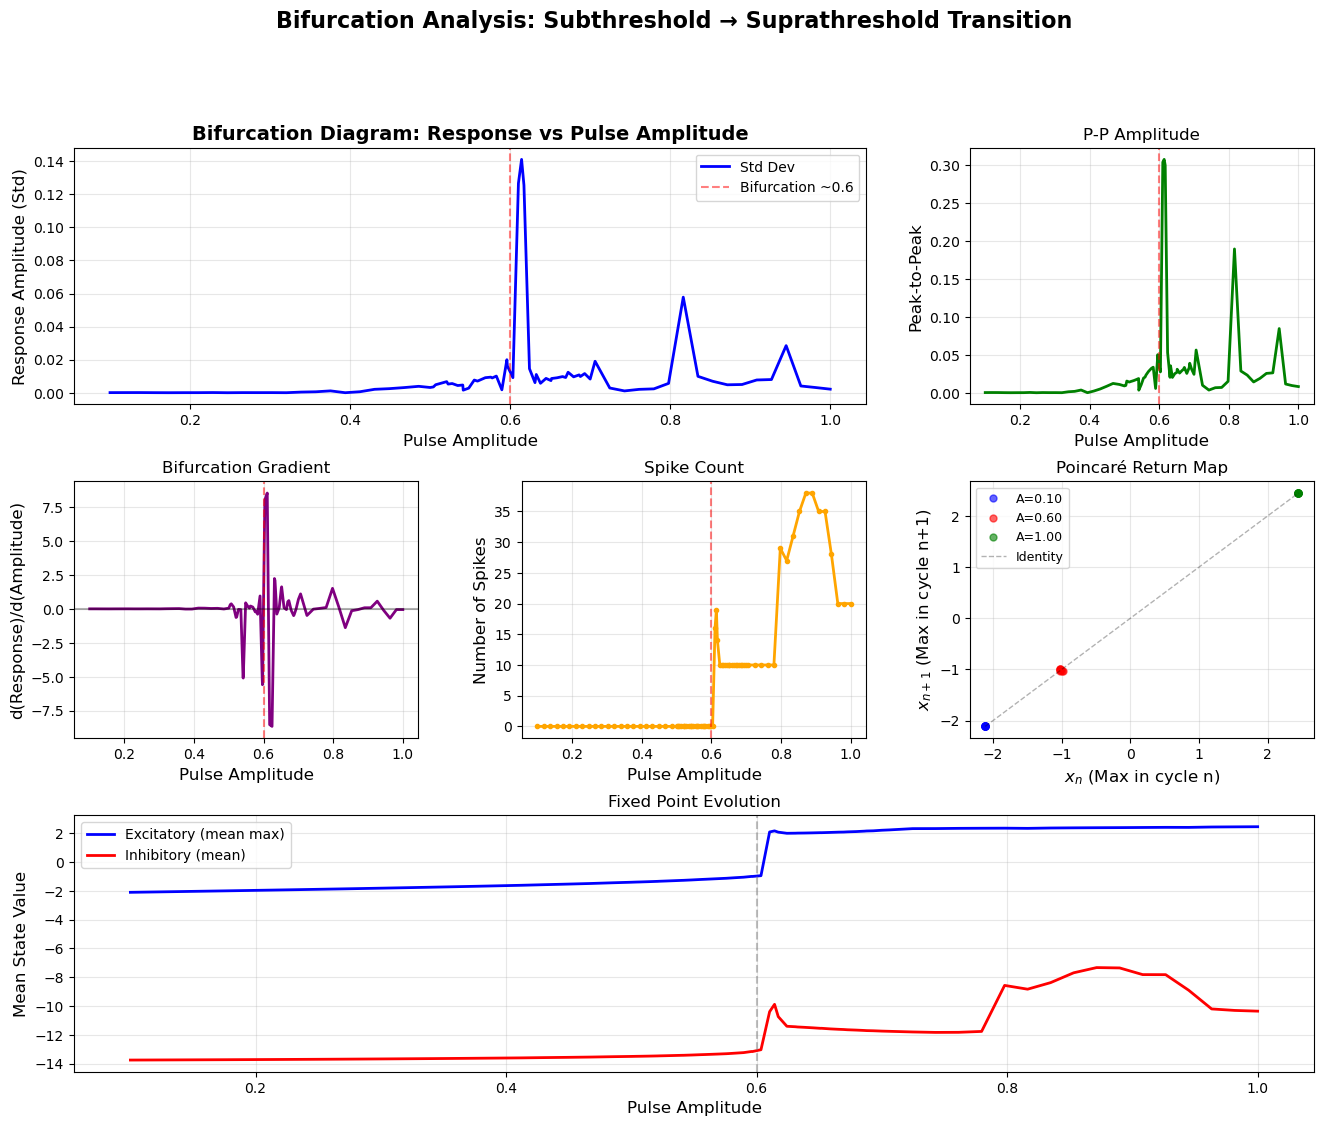

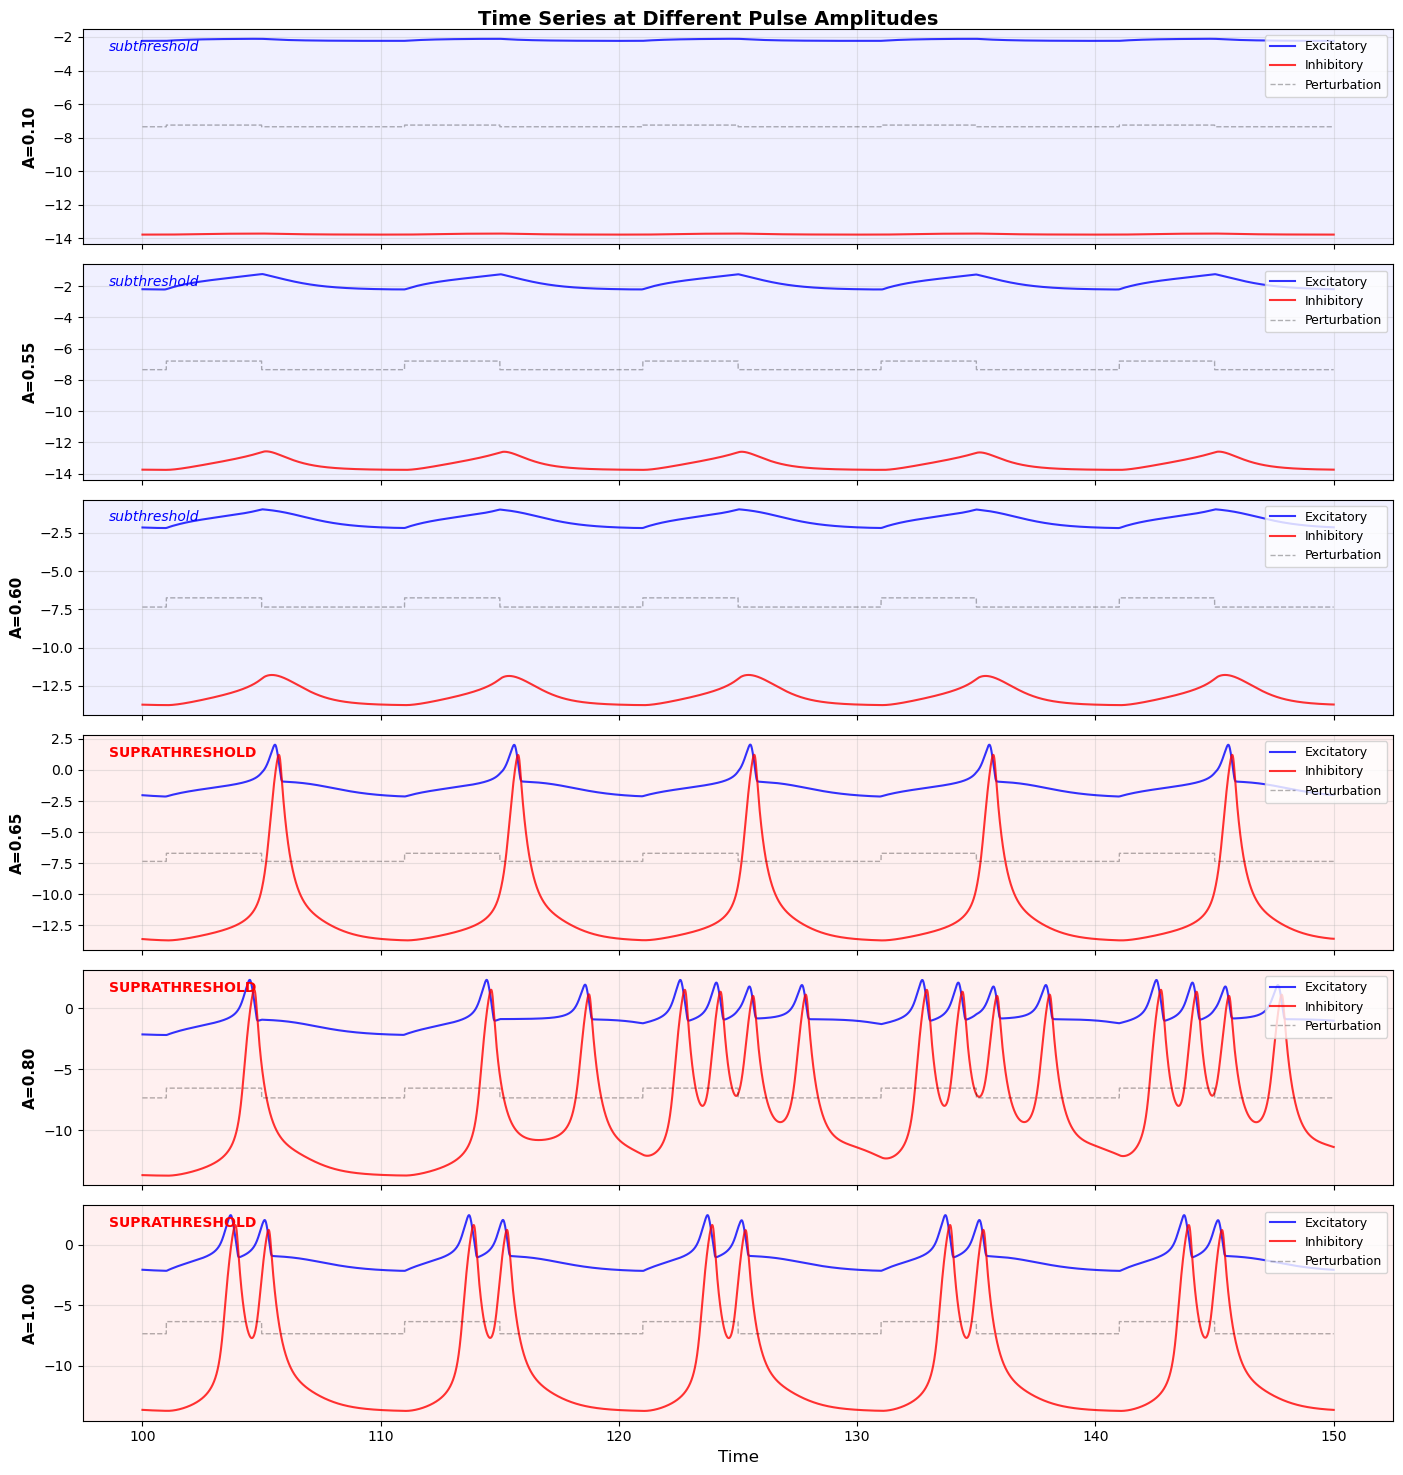

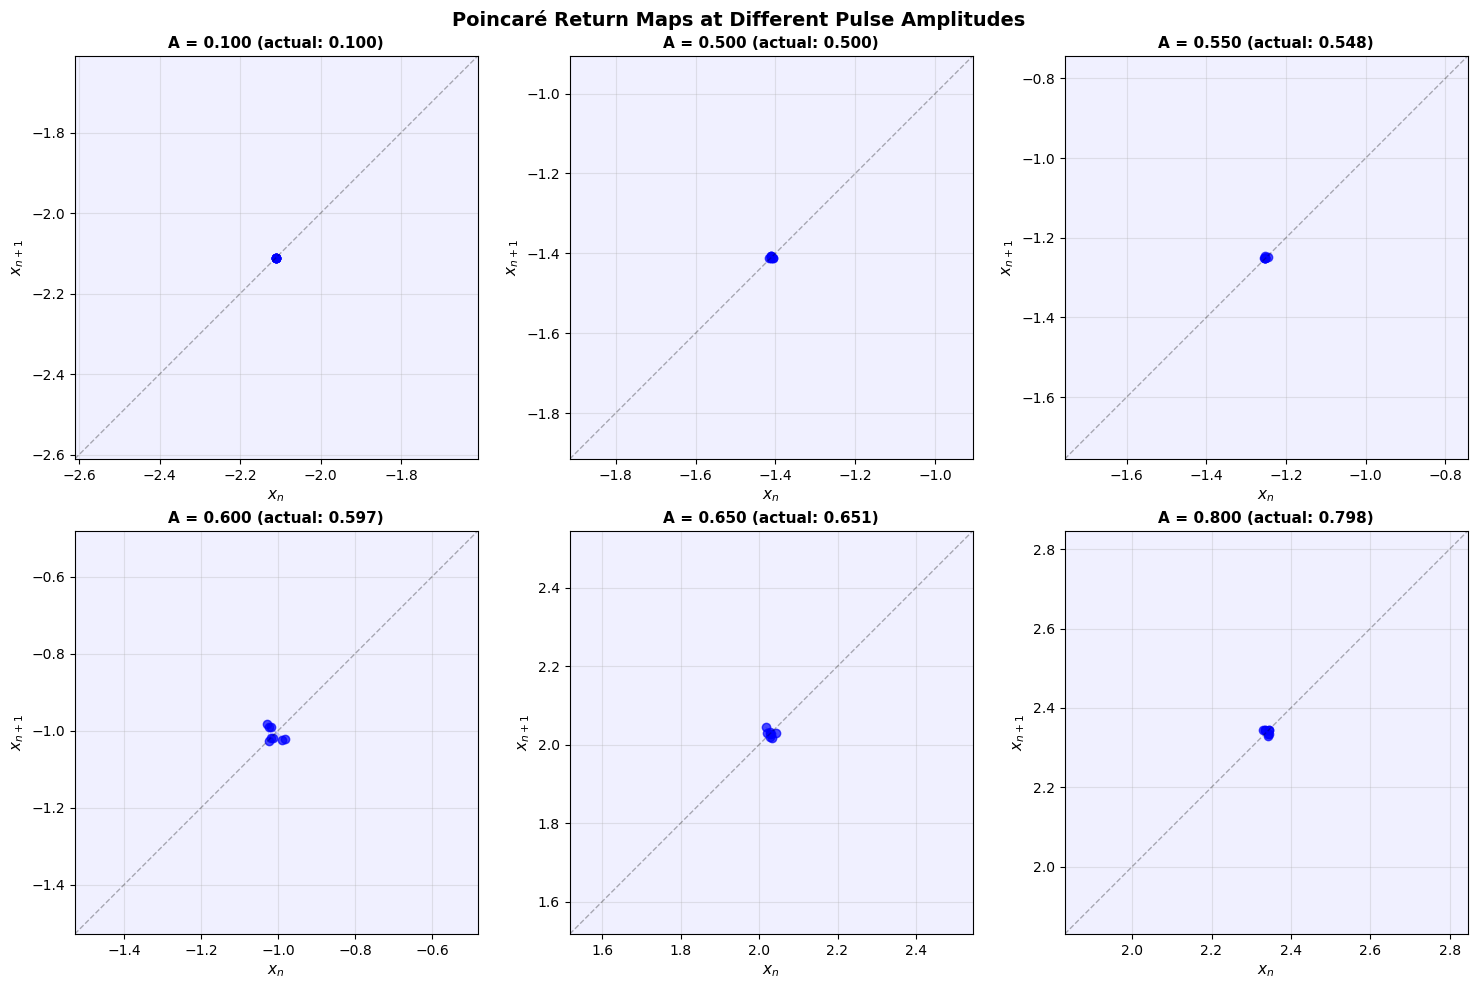


Estimated bifurcation point: 0.6103
Maximum gradient: 8.5299


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


def extract_poincare_section(t, y, pulse_per, transient=50):
    """Extract Poincaré section - now captures max response in each cycle"""
    
    # Find pulse times (start of each cycle)
    cycle_starts = np.arange(0, t[-1], pulse_per)
    cycle_starts = cycle_starts[cycle_starts > transient]
    
    # For each cycle, find the maximum excitatory value
    poincare_max = []
    poincare_at_start = []
    
    for i, t_start in enumerate(cycle_starts):
        t_end = t_start + pulse_per
        
        # Find indices for this cycle
        cycle_idx = (t >= t_start) & (t < t_end)
        
        if np.any(cycle_idx):
            # Maximum in this cycle (captures spike peak)
            poincare_max.append(np.max(y[cycle_idx, 0]))
            
            # Value at cycle start (for comparison)
            start_idx = np.argmin(np.abs(t - t_start))
            poincare_at_start.append(y[start_idx, 0])
    
    return cycle_starts, np.array(poincare_max), np.array(poincare_at_start)

def compute_response_amplitude(poincare_max):
    """Compute response amplitude from Poincaré section"""
    
    if len(poincare_max) < 2:
        return 0.0, 0.0
    
    # Use standard deviation as measure of oscillation amplitude
    std = np.std(poincare_max)
    
    # Also compute peak-to-peak
    ptp = np.ptp(poincare_max)
    
    return std, ptp

def simulate_pulses(pulse_amp, h_ex_0=-7.35, h_in_0=-4.0, 
                    pars=(1, 2.5, 10, 0, 5, 10),
                    y_ini=[-2.24, -13.77],
                    time_stop=150, sr=1000,
                    pulse_wid=4., pulse_per=10):
    """Simulate the system for given pulse amplitude"""
    
    time = np.linspace(start=0, stop=time_stop, num=time_stop*sr)
    pert = h_ex_0 + pulse_amp*ss.rect(
        np.mod(time, pulse_per)-(pulse_per)/2+pulse_wid/2, pulse_wid)
    
    solution = solve_ivp(
        fun=one_oscillator, 
        t_span=(0, time_stop), 
        y0=y_ini,
        args=(h_in_0, pars, sr, time_stop, pert),
        t_eval=time, 
        method='BDF', 
        max_step=0.1
    )
    
    return solution.t, solution.y.T, pert

def bifurcation_analysis(pulse_amps=None, n_amps=100, **kwargs):
    """Comprehensive bifurcation analysis"""
    
    if pulse_amps is None:
        pulse_amps = np.linspace(0.1, 1.0, n_amps)
    
    results = {
        'pulse_amps': pulse_amps,
        'response_std': [],
        'response_ptp': [],
        'poincare_max': [],  # Maximum in each cycle
        'poincare_start': [],  # Value at cycle start
        'fixed_point_ex': [],
        'fixed_point_in': [],
        'n_peaks': []
    }
    
    print("Running bifurcation analysis...")
    for i, amp in enumerate(pulse_amps):
        if i % 10 == 0:
            print(f"  Progress: {i}/{len(pulse_amps)} ({amp:.3f})")
        
        # Simulate
        t, y, pert = simulate_pulses(amp, **kwargs)
        
        # Extract Poincaré section (now captures max in each cycle)
        cycle_starts, poincare_max, poincare_start = extract_poincare_section(
            t, y, kwargs.get('pulse_per', 10)
        )
        
        # Compute response metrics
        std, ptp = compute_response_amplitude(poincare_max)
        results['response_std'].append(std)
        results['response_ptp'].append(ptp)
        results['poincare_max'].append(poincare_max)
        results['poincare_start'].append(poincare_start)
        results['fixed_point_ex'].append(np.mean(poincare_max))
        results['fixed_point_in'].append(np.mean(y[t > 50, 1]))
        
        # Count peaks in excitatory variable (after transient)
        transient_idx = np.where(t > 50)[0][0]
        peaks, _ = find_peaks(y[transient_idx:, 0], height=0, distance=500)
        results['n_peaks'].append(len(peaks))
    
    # Convert to arrays
    for key in ['response_std', 'response_ptp', 'fixed_point_ex', 
                'fixed_point_in', 'n_peaks']:
        results[key] = np.array(results[key])
    
    return results

def plot_bifurcation_diagram(results, highlight_amps=[0.1, 0.6, 1.0]):
    """Comprehensive bifurcation visualization"""
    
    fig = plt.figure(figsize=(16, 12))
    gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)
    
    pulse_amps = results['pulse_amps']
    
    # 1. Response amplitude bifurcation diagram
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(pulse_amps, results['response_std'], 'b-', linewidth=2, label='Std Dev')
    ax1.axvline(0.6, color='r', linestyle='--', alpha=0.5, label='Bifurcation ~0.6')
    ax1.set_xlabel('Pulse Amplitude', fontsize=12)
    ax1.set_ylabel('Response Amplitude (Std)', fontsize=12)
    ax1.set_title('Bifurcation Diagram: Response vs Pulse Amplitude', fontsize=14, weight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 2. Peak-to-peak amplitude
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.plot(pulse_amps, results['response_ptp'], 'g-', linewidth=2)
    ax2.axvline(0.6, color='r', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Pulse Amplitude', fontsize=12)
    ax2.set_ylabel('Peak-to-Peak', fontsize=12)
    ax2.set_title('P-P Amplitude', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # 3. Derivative/gradient of response
    ax3 = fig.add_subplot(gs[1, 0])
    gradient = np.gradient(results['response_std'], pulse_amps)
    ax3.plot(pulse_amps, gradient, 'purple', linewidth=2)
    ax3.axvline(0.6, color='r', linestyle='--', alpha=0.5)
    ax3.axhline(0, color='k', linestyle='-', alpha=0.3)
    ax3.set_xlabel('Pulse Amplitude', fontsize=12)
    ax3.set_ylabel('d(Response)/d(Amplitude)', fontsize=12)
    ax3.set_title('Bifurcation Gradient', fontsize=12)
    ax3.grid(True, alpha=0.3)
    
    # 4. Number of peaks (firing events)
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(pulse_amps, results['n_peaks'], 'orange', linewidth=2, marker='o', markersize=3)
    ax4.axvline(0.6, color='r', linestyle='--', alpha=0.5)
    ax4.set_xlabel('Pulse Amplitude', fontsize=12)
    ax4.set_ylabel('Number of Spikes', fontsize=12)
    ax4.set_title('Spike Count', fontsize=12)
    ax4.grid(True, alpha=0.3)
    
    # 5. Poincaré return map for selected amplitudes - NOW FIXED!
    ax5 = fig.add_subplot(gs[1, 2])
    colors = ['blue', 'red', 'green']
    for amp, color in zip(highlight_amps, colors):
        idx = np.argmin(np.abs(pulse_amps - amp))
        states = results['poincare_max'][idx]  # Use max values now
        if len(states) > 1:
            ax5.plot(states[:-1], states[1:], 'o', color=color, 
                    alpha=0.6, markersize=5, label=f'A={amp:.2f}')
    
    # Add diagonal
    all_states = []
    for states in results['poincare_max']:
        all_states.extend(states)
    all_states = np.array(all_states)
    lim = [all_states.min(), all_states.max()]
    ax5.plot(lim, lim, 'k--', alpha=0.3, linewidth=1, label='Identity')
    
    ax5.set_xlabel('$x_n$ (Max in cycle n)', fontsize=12)
    ax5.set_ylabel('$x_{n+1}$ (Max in cycle n+1)', fontsize=12)
    ax5.set_title('Poincaré Return Map', fontsize=12)
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)
    
    # 6. Fixed point trajectories
    ax6 = fig.add_subplot(gs[2, :])
    ax6.plot(pulse_amps, results['fixed_point_ex'], 'b-', linewidth=2, label='Excitatory (mean max)')
    ax6.plot(pulse_amps, results['fixed_point_in'], 'r-', linewidth=2, label='Inhibitory (mean)')
    ax6.axvline(0.6, color='gray', linestyle='--', alpha=0.5)
    ax6.set_xlabel('Pulse Amplitude', fontsize=12)
    ax6.set_ylabel('Mean State Value', fontsize=12)
    ax6.set_title('Fixed Point Evolution', fontsize=12)
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    plt.suptitle('Bifurcation Analysis: Subthreshold → Suprathreshold Transition', 
                 fontsize=16, weight='bold', y=0.995)
    
    return fig

def plot_detailed_return_map(results, pulse_amps_to_show=[0.1, 0.5, 0.55, 0.6, 0.65, 0.8]):
    """Detailed view of return maps at different amplitudes"""
    
    n = len(pulse_amps_to_show)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, amp in enumerate(pulse_amps_to_show):
        idx = np.argmin(np.abs(results['pulse_amps'] - amp))
        states = results['poincare_max'][idx]
        
        ax = axes[i]
        
        if len(states) > 1:
            # Plot return map
            ax.plot(states[:-1], states[1:], 'o', color='blue', 
                   alpha=0.7, markersize=6)
            
            # Add diagonal
            lim = [states.min() - 0.5, states.max() + 0.5]
            ax.plot(lim, lim, 'k--', alpha=0.3, linewidth=1)
            
            # Add connecting lines to show trajectory
            ax.plot(states[:-1], states[1:], '-', color='blue', 
                   alpha=0.2, linewidth=0.5)
            
            ax.set_xlim(lim)
            ax.set_ylim(lim)
        
        ax.set_xlabel('$x_n$', fontsize=11)
        ax.set_ylabel('$x_{n+1}$', fontsize=11)
        ax.set_title(f'A = {amp:.3f} (actual: {results["pulse_amps"][idx]:.3f})', 
                    fontsize=11, weight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        
        # Color code by regime
        std = results['response_std'][idx]
        if std < 0.5:
            ax.set_facecolor('#f0f0ff')
        else:
            ax.set_facecolor('#fff0f0')
    
    plt.suptitle('Poincaré Return Maps at Different Pulse Amplitudes', 
                fontsize=14, weight='bold')
    plt.tight_layout()
    
    return fig

def plot_example_timeseries(pulse_amps=[0.1, 0.55, 0.6, 0.8, 1.0], **kwargs):
    """Plot example timeseries at different pulse amplitudes"""
    
    n = len(pulse_amps)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5*n), sharex=True)
    
    for i, amp in enumerate(pulse_amps):
        t, y, pert = simulate_pulses(amp, **kwargs)
        
        # Plot only last 50 seconds to see steady state
        idx = t > 100
        
        ax = axes[i] if n > 1 else axes
        ax.plot(t[idx], y[idx, 0], 'b-', linewidth=1.5, label='Excitatory', alpha=0.8)
        ax.plot(t[idx], y[idx, 1], 'r-', linewidth=1.5, label='Inhibitory', alpha=0.8)
        ax.plot(t[idx], pert[idx], 'k--', linewidth=1, alpha=0.3, label='Perturbation')
        
        ax.set_ylabel(f'A={amp:.2f}', fontsize=11, weight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=9)
        
        # Mark if suprathreshold
        if np.std(y[idx, 0]) > 0.5:
            ax.set_facecolor('#fff0f0')
            ax.text(0.02, 0.95, 'SUPRATHRESHOLD', transform=ax.transAxes,
                   fontsize=10, weight='bold', color='red', va='top')
        else:
            ax.set_facecolor('#f0f0ff')
            ax.text(0.02, 0.95, 'subthreshold', transform=ax.transAxes,
                   fontsize=10, style='italic', color='blue', va='top')
    
    axes[-1].set_xlabel('Time', fontsize=12)
    plt.suptitle('Time Series at Different Pulse Amplitudes', fontsize=14, weight='bold')
    plt.tight_layout()
    
    return fig

# Update the main execution
if __name__ == "__main__":
    # Run bifurcation analysis with high resolution around critical point
    pulse_amps_coarse = np.linspace(0.1, 1.0, 50)
    pulse_amps_fine = np.linspace(0.5, 0.7, 30)  # Fine resolution around bifurcation
    pulse_amps = np.sort(np.concatenate([pulse_amps_coarse, pulse_amps_fine]))
    
    results = bifurcation_analysis(pulse_amps=pulse_amps)
    
    # Plot results
    fig1 = plot_bifurcation_diagram(results)
    plt.savefig('bifurcation_analysis.png', dpi=150, bbox_inches='tight')
    
    fig2 = plot_example_timeseries(pulse_amps=[0.1, 0.55, 0.6, 0.65, 0.8, 1.0])
    plt.savefig('timeseries_examples.png', dpi=150, bbox_inches='tight')
    
    # NEW: Detailed return map visualization
    fig3 = plot_detailed_return_map(results, 
                                     pulse_amps_to_show=[0.1, 0.5, 0.55, 0.6, 0.65, 0.8])
    plt.savefig('return_maps_detailed.png', dpi=150, bbox_inches='tight')
    
    plt.show()
    
    # Print bifurcation point estimate
    gradient = np.gradient(results['response_std'], results['pulse_amps'])
    bifurcation_idx = np.argmax(gradient)
    print(f"\nEstimated bifurcation point: {results['pulse_amps'][bifurcation_idx]:.4f}")
    print(f"Maximum gradient: {gradient[bifurcation_idx]:.4f}")

HYSTERESIS ANALYSIS: Testing for bistability

--- Scan WITH state continuation (reveals bistability) ---
Running forward scan...
  Progress: 0/60 (0.580)
  Progress: 10/60 (0.588)
  Progress: 20/60 (0.597)
  Progress: 30/60 (0.605)
  Progress: 40/60 (0.614)
  Progress: 50/60 (0.622)
Running backward scan...
  Progress: 0/60 (0.630)
  Progress: 10/60 (0.622)
  Progress: 20/60 (0.613)
  Progress: 30/60 (0.605)
  Progress: 40/60 (0.596)
  Progress: 50/60 (0.588)

*** HYSTERESIS DETECTED ***
Maximum difference at A = 0.6063
Hysteresis width: 1.1976

--- Scan WITHOUT state continuation (fresh IC each time) ---
Running forward scan...
  Progress: 0/60 (0.580)
  Progress: 10/60 (0.588)
  Progress: 20/60 (0.597)
  Progress: 30/60 (0.605)
  Progress: 40/60 (0.614)
  Progress: 50/60 (0.622)
Running backward scan...
  Progress: 0/60 (0.630)
  Progress: 10/60 (0.622)
  Progress: 20/60 (0.613)
  Progress: 30/60 (0.605)
  Progress: 40/60 (0.596)
  Progress: 50/60 (0.588)

*** NO HYSTERESIS DETECTED 

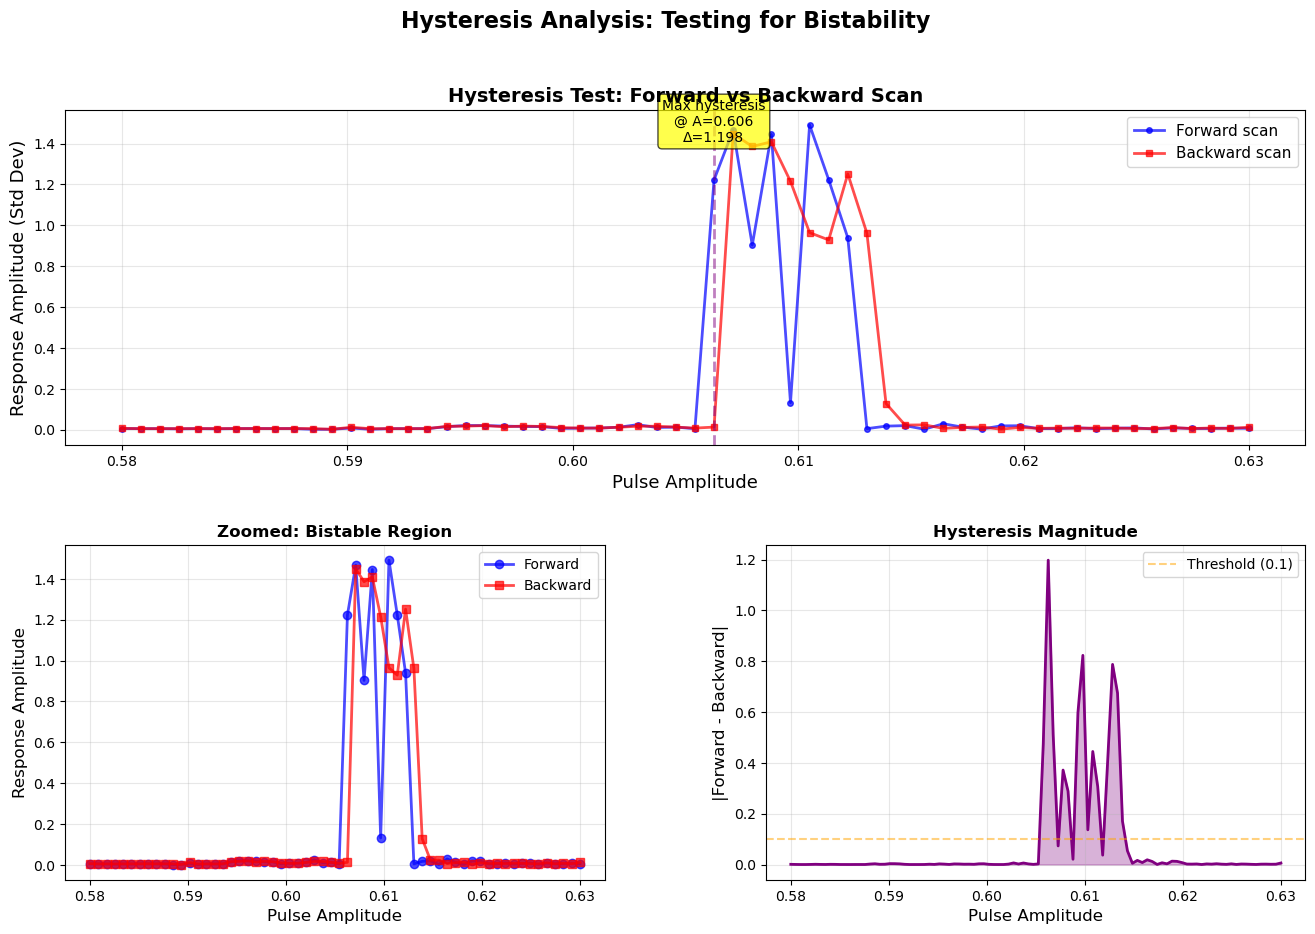

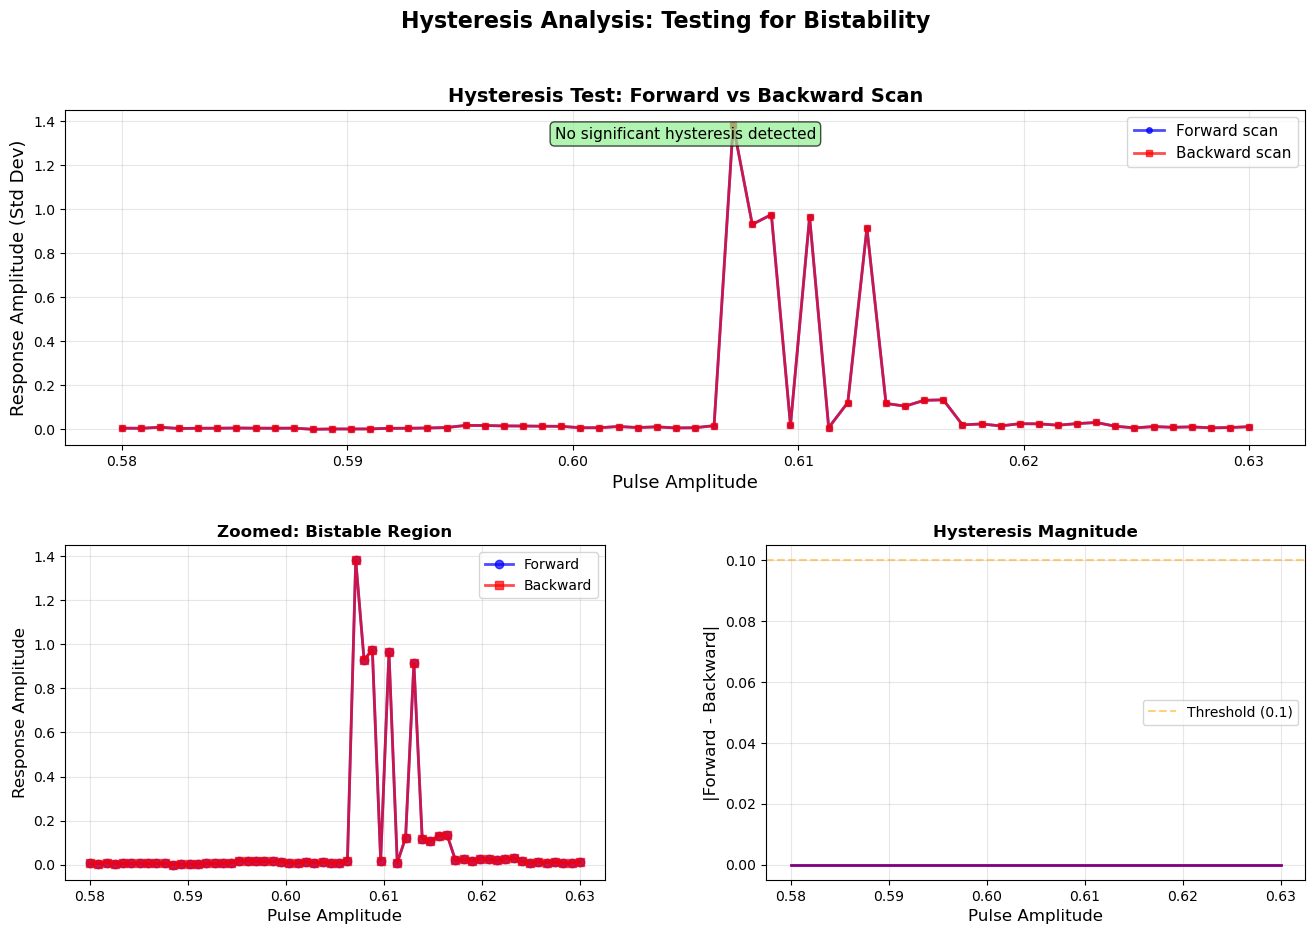

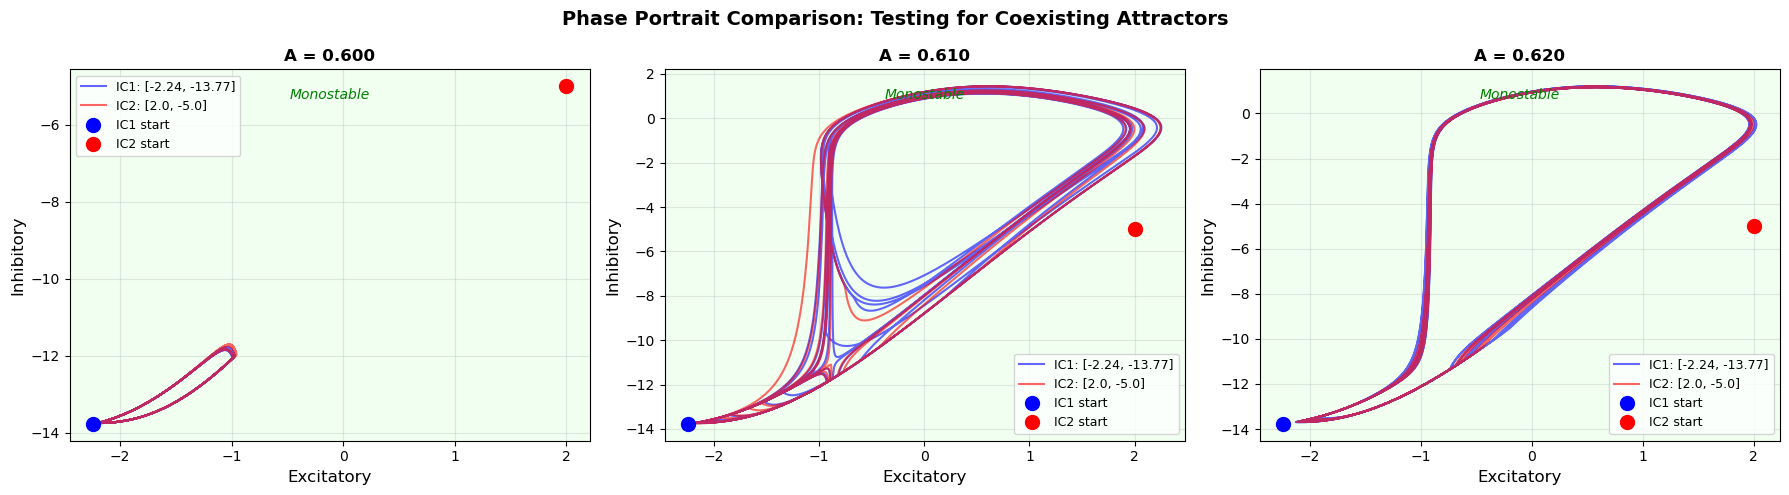


SUMMARY
With continuation:    Max hysteresis = 1.1976 at A = 0.6063
Without continuation: Max hysteresis = 0.0000 at A = 0.5800

*** BORDER-COLLISION/GRAZING bifurcation with BISTABILITY ***
The system exhibits hysteresis when scanning direction matters.


In [12]:
def bifurcation_analysis_with_hysteresis(pulse_amps_forward=None, pulse_amps_backward=None, 
                                         n_amps=100, use_previous_state=True, **kwargs):
    """
    Bifurcation analysis scanning forward and backward to detect hysteresis.
    
    Parameters:
    -----------
    use_previous_state : bool
        If True, use the final state from previous amplitude as initial condition
        for next amplitude (reveals bistability)
    """
    
    if pulse_amps_forward is None:
        pulse_amps_forward = np.linspace(0.58, 0.63, n_amps)
    if pulse_amps_backward is None:
        pulse_amps_backward = np.linspace(0.63, 0.58, n_amps)
    
    def run_scan(pulse_amps, direction='forward'):
        """Run one directional scan"""
        results = {
            'pulse_amps': pulse_amps,
            'response_std': [],
            'response_ptp': [],
            'poincare_max': [],
            'fixed_point_ex': [],
            'final_state': [],  # Store final state for next simulation
            'n_peaks': []
        }
        
        # Initial condition (only used for first simulation if use_previous_state=False)
        current_y_ini = kwargs.get('y_ini', [-2.24, -13.77])
        
        print(f"Running {direction} scan...")
        for i, amp in enumerate(pulse_amps):
            if i % 10 == 0:
                print(f"  Progress: {i}/{len(pulse_amps)} ({amp:.3f})")
            
            # Use previous final state as initial condition if requested
            if use_previous_state and i > 0:
                sim_kwargs = {**kwargs, 'y_ini': current_y_ini}
            else:
                sim_kwargs = kwargs
            
            # Simulate
            t, y, pert = simulate_pulses(amp, **sim_kwargs)
            
            # Store final state for next iteration
            current_y_ini = [y[-1, 0], y[-1, 1]]
            
            # Extract Poincaré section
            cycle_starts, poincare_max, poincare_start = extract_poincare_section(
                t, y, kwargs.get('pulse_per', 10)
            )
            
            # Compute response metrics
            std, ptp = compute_response_amplitude(poincare_max)
            results['response_std'].append(std)
            results['response_ptp'].append(ptp)
            results['poincare_max'].append(poincare_max)
            results['fixed_point_ex'].append(np.mean(poincare_max))
            results['final_state'].append(current_y_ini)
            
            # Count peaks
            transient_idx = np.where(t > 50)[0][0]
            peaks, _ = find_peaks(y[transient_idx:, 0], height=0, distance=500)
            results['n_peaks'].append(len(peaks))
        
        # Convert to arrays
        for key in ['response_std', 'response_ptp', 'fixed_point_ex', 'n_peaks']:
            results[key] = np.array(results[key])
        
        return results
    
    # Run both scans
    results_forward = run_scan(pulse_amps_forward, 'forward')
    results_backward = run_scan(pulse_amps_backward, 'backward')
    
    return results_forward, results_backward

def plot_hysteresis_analysis(results_forward, results_backward, zoom_range=None):
    """
    Plot bifurcation diagrams with forward and backward scans to reveal hysteresis.
    
    Parameters:
    -----------
    zoom_range : tuple or None
        If provided, (amp_min, amp_max) to zoom into bistable region
    """
    
    fig = plt.figure(figsize=(16, 10))
    gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)
    
    # 1. Full bifurcation diagram with hysteresis
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(results_forward['pulse_amps'], results_forward['response_std'], 
             'b-o', linewidth=2, markersize=4, label='Forward scan', alpha=0.7)
    ax1.plot(results_backward['pulse_amps'], results_backward['response_std'], 
             'r-s', linewidth=2, markersize=4, label='Backward scan', alpha=0.7)
    
    ax1.set_xlabel('Pulse Amplitude', fontsize=13)
    ax1.set_ylabel('Response Amplitude (Std Dev)', fontsize=13)
    ax1.set_title('Hysteresis Test: Forward vs Backward Scan', fontsize=14, weight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Check for hysteresis
    # Interpolate to compare at same amplitudes
    amps_common = np.linspace(
        max(results_forward['pulse_amps'].min(), results_backward['pulse_amps'].min()),
        min(results_forward['pulse_amps'].max(), results_backward['pulse_amps'].max()),
        100
    )
    
    from scipy.interpolate import interp1d
    forward_interp = interp1d(results_forward['pulse_amps'], 
                              results_forward['response_std'], 
                              kind='linear', fill_value='extrapolate')
    backward_interp = interp1d(results_backward['pulse_amps'], 
                               results_backward['response_std'], 
                               kind='linear', fill_value='extrapolate')
    
    difference = np.abs(forward_interp(amps_common) - backward_interp(amps_common))
    max_diff_idx = np.argmax(difference)
    max_diff = difference[max_diff_idx]
    max_diff_amp = amps_common[max_diff_idx]
    
    if max_diff > 0.1:  # Significant hysteresis
        ax1.axvline(max_diff_amp, color='purple', linestyle='--', alpha=0.5, linewidth=2)
        ax1.text(max_diff_amp, ax1.get_ylim()[1]*0.9, 
                f'Max hysteresis\n@ A={max_diff_amp:.3f}\nΔ={max_diff:.3f}',
                ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
        print(f"\n*** HYSTERESIS DETECTED ***")
        print(f"Maximum difference at A = {max_diff_amp:.4f}")
        print(f"Hysteresis width: {max_diff:.4f}")
    else:
        ax1.text(0.5, 0.95, 'No significant hysteresis detected', 
                transform=ax1.transAxes, ha='center', va='top',
                fontsize=11, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
        print(f"\n*** NO HYSTERESIS DETECTED ***")
        print(f"Maximum difference: {max_diff:.4f}")
    
    # 2. Zoomed view of bistable region (if zoom_range provided)
    if zoom_range is not None:
        ax2 = fig.add_subplot(gs[1, 0])
        amp_min, amp_max = zoom_range
        
        # Filter data to zoom range
        forward_mask = (results_forward['pulse_amps'] >= amp_min) & \
                      (results_forward['pulse_amps'] <= amp_max)
        backward_mask = (results_backward['pulse_amps'] >= amp_min) & \
                       (results_backward['pulse_amps'] <= amp_max)
        
        ax2.plot(results_forward['pulse_amps'][forward_mask], 
                results_forward['response_std'][forward_mask], 
                'b-o', linewidth=2, markersize=6, label='Forward', alpha=0.7)
        ax2.plot(results_backward['pulse_amps'][backward_mask], 
                results_backward['response_std'][backward_mask], 
                'r-s', linewidth=2, markersize=6, label='Backward', alpha=0.7)
        
        ax2.set_xlabel('Pulse Amplitude', fontsize=12)
        ax2.set_ylabel('Response Amplitude', fontsize=12)
        ax2.set_title('Zoomed: Bistable Region', fontsize=12, weight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # 3. Difference plot
    ax3 = fig.add_subplot(gs[1, 1] if zoom_range else gs[1, :])
    ax3.plot(amps_common, difference, 'purple', linewidth=2)
    ax3.fill_between(amps_common, 0, difference, alpha=0.3, color='purple')
    ax3.axhline(0.1, color='orange', linestyle='--', alpha=0.5, 
                label='Threshold (0.1)')
    ax3.set_xlabel('Pulse Amplitude', fontsize=12)
    ax3.set_ylabel('|Forward - Backward|', fontsize=12)
    ax3.set_title('Hysteresis Magnitude', fontsize=12, weight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    plt.suptitle('Hysteresis Analysis: Testing for Bistability', 
                 fontsize=16, weight='bold', y=0.98)
    
    return fig, max_diff, max_diff_amp

def plot_phase_portraits_comparison(pulse_amps=[0.6, 0.61, 0.62], **kwargs):
    """
    Compare phase portraits at critical amplitudes with different initial conditions
    to test for coexisting attractors (bistability).
    """
    
    n = len(pulse_amps)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1:
        axes = [axes]
    
    # Test with two different initial conditions
    ic1 = kwargs.get('y_ini', [-2.24, -13.77])  # Default "down" state
    ic2 = [2.0, -5.0]  # "Up" state to test bistability
    
    for i, amp in enumerate(pulse_amps):
        ax = axes[i]
        
        # Simulate from both initial conditions
        t1, y1, _ = simulate_pulses(amp, y_ini=ic1, **kwargs)
        t2, y2, _ = simulate_pulses(amp, y_ini=ic2, **kwargs)
        
        # Plot phase portraits (after transient)
        transient_idx = int(50 * kwargs.get('sr', 1000))
        
        ax.plot(y1[transient_idx:, 0], y1[transient_idx:, 1], 
               'b-', linewidth=1.5, alpha=0.6, label=f'IC1: {ic1}')
        ax.plot(y2[transient_idx:, 0], y2[transient_idx:, 1], 
               'r-', linewidth=1.5, alpha=0.6, label=f'IC2: {ic2}')
        
        # Mark initial conditions
        ax.plot(ic1[0], ic1[1], 'bo', markersize=10, label='IC1 start')
        ax.plot(ic2[0], ic2[1], 'ro', markersize=10, label='IC2 start')
        
        ax.set_xlabel('Excitatory', fontsize=12)
        ax.set_ylabel('Inhibitory', fontsize=12)
        ax.set_title(f'A = {amp:.3f}', fontsize=12, weight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        
        # Check if they converge to same attractor
        final_dist = np.sqrt((y1[-1, 0] - y2[-1, 0])**2 + 
                            (y1[-1, 1] - y2[-1, 1])**2)
        
        if final_dist > 1.0:  # Different attractors
            ax.set_facecolor('#fff0f0')
            ax.text(0.5, 0.95, 'BISTABLE', transform=ax.transAxes,
                   ha='center', va='top', fontsize=11, weight='bold', 
                   color='red', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
        else:
            ax.set_facecolor('#f0fff0')
            ax.text(0.5, 0.95, 'Monostable', transform=ax.transAxes,
                   ha='center', va='top', fontsize=10, style='italic', color='green')
    
    plt.suptitle('Phase Portrait Comparison: Testing for Coexisting Attractors', 
                 fontsize=14, weight='bold')
    plt.tight_layout()
    
    return fig

# Update main execution
if __name__ == "__main__":
    print("="*60)
    print("HYSTERESIS ANALYSIS: Testing for bistability")
    print("="*60)
    
    # Define amplitude ranges
    pulse_amps_forward = np.linspace(0.58, 0.63, 60)
    pulse_amps_backward = np.linspace(0.63, 0.58, 60)
    
    # Run hysteresis analysis WITH state continuation
    print("\n--- Scan WITH state continuation (reveals bistability) ---")
    results_fwd_cont, results_bwd_cont = bifurcation_analysis_with_hysteresis(
        pulse_amps_forward, pulse_amps_backward, use_previous_state=True
    )
    
    fig_hyst_cont, diff_cont, amp_cont = plot_hysteresis_analysis(
        results_fwd_cont, results_bwd_cont, zoom_range=(0.58, 0.63)
    )
    plt.savefig('hysteresis_with_continuation.png', dpi=150, bbox_inches='tight')
    
    # Run hysteresis analysis WITHOUT state continuation (fresh IC each time)
    print("\n--- Scan WITHOUT state continuation (fresh IC each time) ---")
    results_fwd_fresh, results_bwd_fresh = bifurcation_analysis_with_hysteresis(
        pulse_amps_forward, pulse_amps_backward, use_previous_state=False
    )
    
    fig_hyst_fresh, diff_fresh, amp_fresh = plot_hysteresis_analysis(
        results_fwd_fresh, results_bwd_fresh, zoom_range=(0.56, 0.63)
    )
    plt.savefig('hysteresis_without_continuation.png', dpi=150, bbox_inches='tight')
    
    # Phase portrait comparison at critical amplitudes
    fig_phase = plot_phase_portraits_comparison(
        pulse_amps=[0.60, 0.61, 0.62], 
        time_stop=150, sr=1000, pulse_wid=4., pulse_per=10
    )
    plt.savefig('phase_portraits_bistability_test.png', dpi=150, bbox_inches='tight')
    
    plt.show()
    
    # Summary
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"With continuation:    Max hysteresis = {diff_cont:.4f} at A = {amp_cont:.4f}")
    print(f"Without continuation: Max hysteresis = {diff_fresh:.4f} at A = {amp_fresh:.4f}")
    
    if diff_cont > 0.1:
        print("\n*** BORDER-COLLISION/GRAZING bifurcation with BISTABILITY ***")
        print("The system exhibits hysteresis when scanning direction matters.")
    elif diff_fresh < 0.05:
        print("\n*** Likely a smooth SNIC bifurcation (NO bistability) ***")
        print("No significant hysteresis in either scanning mode.")
    else:
        print("\n*** Intermediate case - further investigation needed ***")

# Comment: the bistability is an artefact due to very long SNIC transients. It gets narrower, the longer transients are allowed. 

SNIC BIFURCATION ANALYSIS
Testing for critical slowing down and period divergence

--- Phase 1: Transient time dependence ---

Short transient (50s)...
Running adaptive transient bifurcation analysis...
  Progress: 0/60 (0.100)
  Progress: 10/60 (0.253)
  Progress: 20/60 (0.405)
  Progress: 30/60 (0.558)
    Using extended transient (50s) for A=0.558
    Using extended transient (50s) for A=0.573
    Using extended transient (50s) for A=0.588
    Using extended transient (50s) for A=0.603
    Using extended transient (50s) for A=0.619
    Using extended transient (50s) for A=0.634
    Using extended transient (50s) for A=0.649
  Progress: 40/60 (0.710)
  Progress: 50/60 (0.863)

Long transient (300s)...
Running adaptive transient bifurcation analysis...
  Progress: 0/60 (0.100)
  Progress: 10/60 (0.253)
  Progress: 20/60 (0.405)
  Progress: 30/60 (0.558)
    Using extended transient (300s) for A=0.558
    Using extended transient (300s) for A=0.573
    Using extended transient (300s) f

/var/folders/cs/lkcj7j890kv6kfxbkl56w9h80000gn/T/ipykernel_90174/445778757.py:311: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


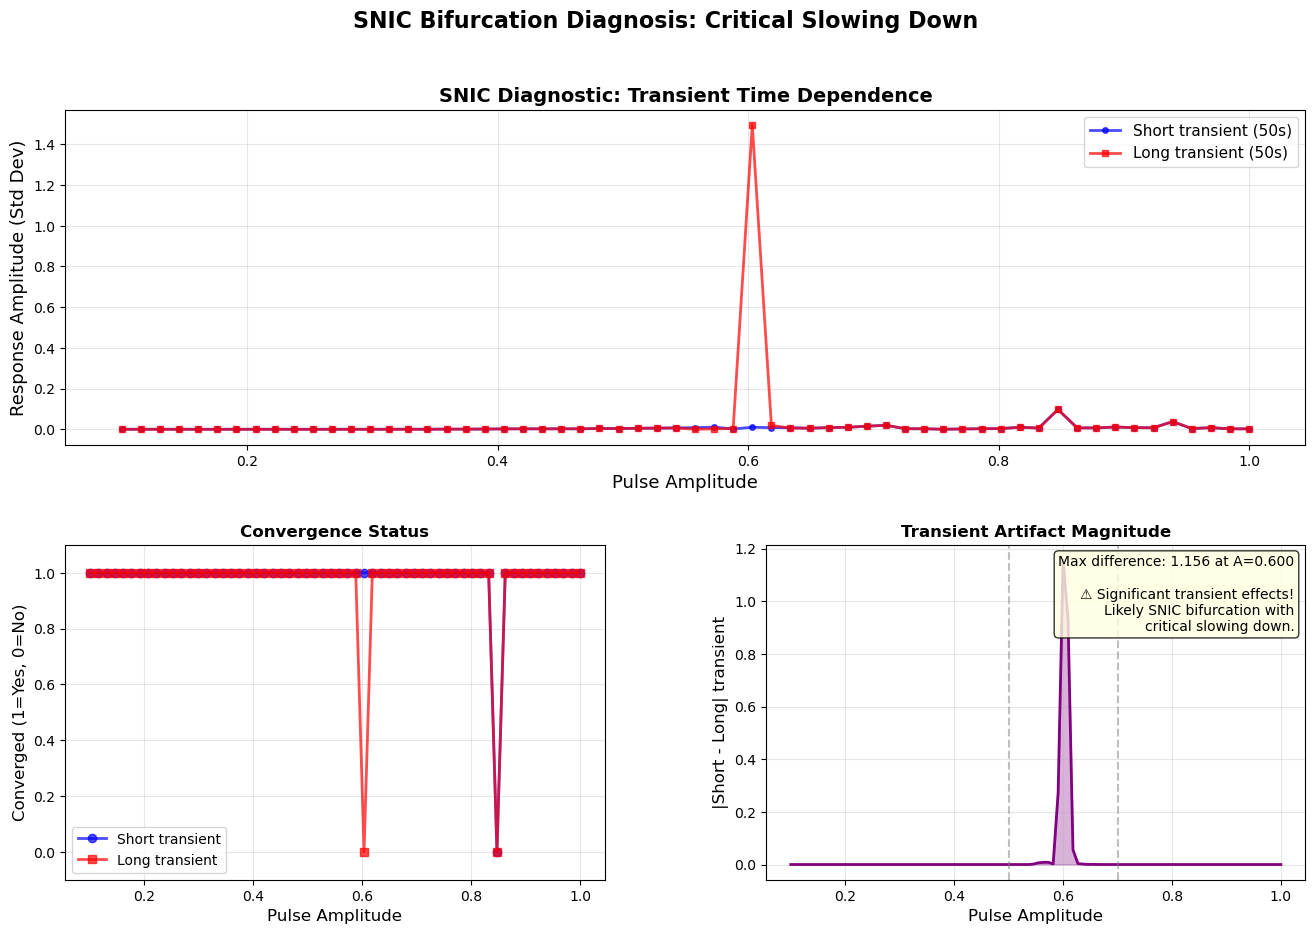

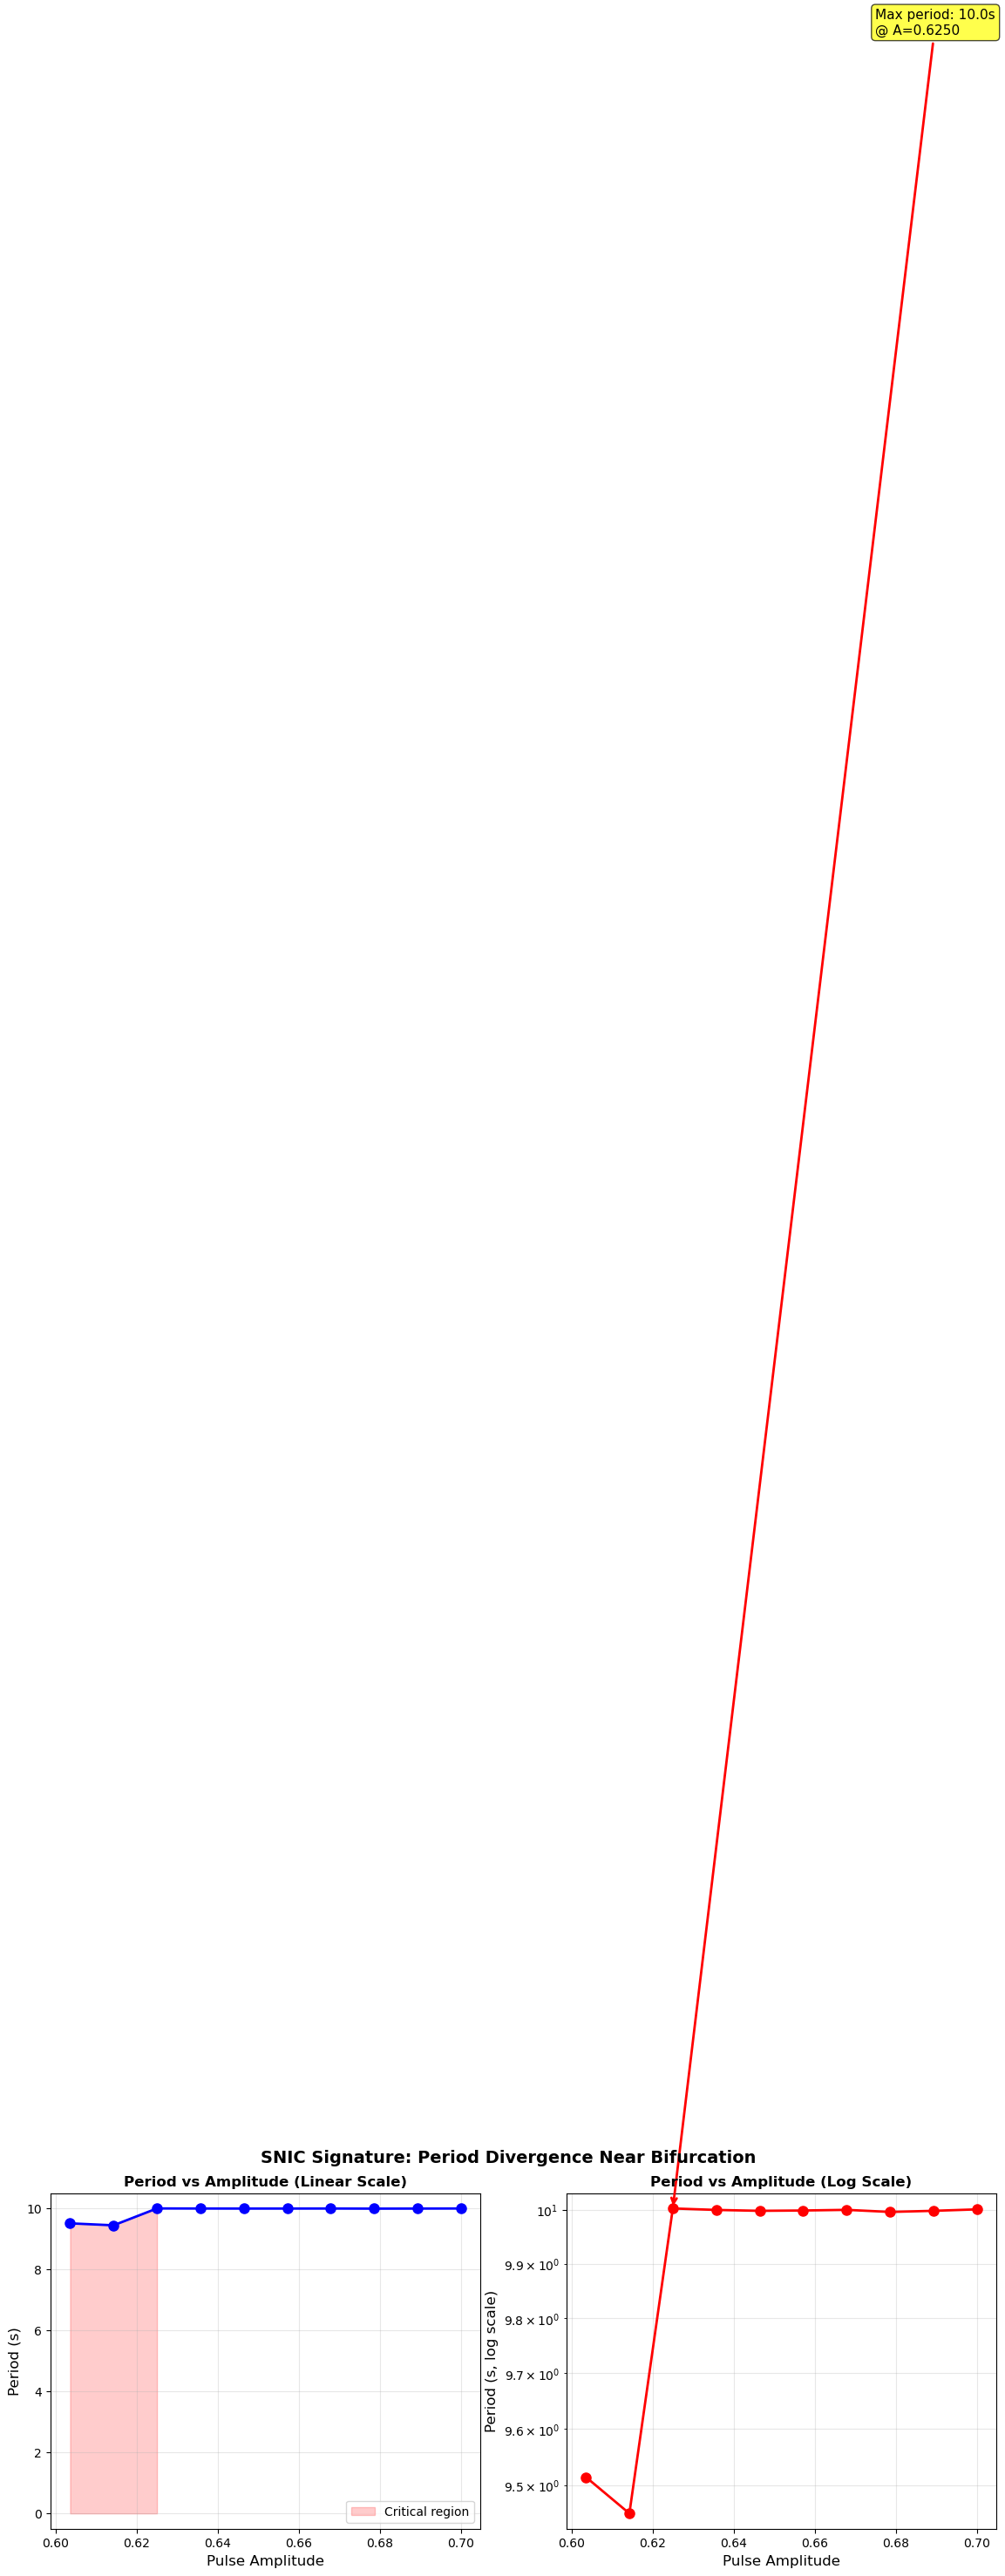


DIAGNOSIS

Maximum transient artifact: 1.4855 at A = 0.6034

*** STRONG EVIDENCE FOR SNIC BIFURCATION ***
- Significant dependence on transient time
- 'Hysteresis' disappears with longer transients
- Critical slowing down near bifurcation

Period variation: 9.4s → 10.0s (ratio: 1.1x)
- Modest period variation


In [14]:
def estimate_transient_time(pulse_amp, h_ex_0=-7.35, h_in_0=-4.0, 
                           pars=(1, 2.5, 10, 0, 5, 10),
                           y_ini=[-2.24, -13.77],
                           pulse_wid=4., pulse_per=10,
                           time_stop_max=500, sr=1000,
                           tolerance=1e-3):
    """
    Estimate the transient time by checking when the system settles to steady state.
    Near SNIC bifurcations, this can be extremely long!
    """
    
    time = np.linspace(start=0, stop=time_stop_max, num=time_stop_max*sr)
    pert = h_ex_0 + pulse_amp*ss.rect(
        np.mod(time, pulse_per)-(pulse_per)/2+pulse_wid/2, pulse_wid)
    
    solution = solve_ivp(
        fun=one_oscillator, 
        t_span=(0, time_stop_max), 
        y0=y_ini,
        args=(h_in_0, pars, sr, time_stop_max, pert),
        t_eval=time, 
        method='BDF', 
        max_step=0.1
    )
    
    t, y = solution.t, solution.y.T
    
    # Look at successive cycles and measure how much they change
    cycle_starts = np.arange(pulse_per, t[-1], pulse_per)
    
    cycle_maxima = []
    for t_start in cycle_starts:
        t_end = t_start + pulse_per
        cycle_idx = (t >= t_start) & (t < t_end)
        if np.any(cycle_idx):
            cycle_maxima.append(np.max(y[cycle_idx, 0]))
    
    cycle_maxima = np.array(cycle_maxima)
    
    # Find when successive cycles stop changing significantly
    if len(cycle_maxima) < 3:
        return time_stop_max, False
    
    # Rolling window comparison
    window = 5
    for i in range(window, len(cycle_maxima)):
        recent_std = np.std(cycle_maxima[i-window:i])
        if recent_std < tolerance:
            transient_time = cycle_starts[i]
            return transient_time, True
    
    # Didn't converge
    return time_stop_max, False

def bifurcation_analysis_adaptive_transient(pulse_amps=None, n_amps=50, 
                                           base_transient=50,
                                           critical_region=(0.55, 0.65),
                                           extended_transient=300,
                                           **kwargs):
    """
    Bifurcation analysis with adaptive transient times.
    Use longer transients near suspected bifurcation point.
    """
    
    if pulse_amps is None:
        pulse_amps = np.linspace(0.1, 1.0, n_amps)
    
    results = {
        'pulse_amps': pulse_amps,
        'response_std': [],
        'response_ptp': [],
        'poincare_max': [],
        'fixed_point_ex': [],
        'n_peaks': [],
        'transient_used': [],
        'converged': []
    }
    
    print("Running adaptive transient bifurcation analysis...")
    for i, amp in enumerate(pulse_amps):
        if i % 10 == 0:
            print(f"  Progress: {i}/{len(pulse_amps)} ({amp:.3f})")
        
        # Decide on transient time
        if critical_region[0] <= amp <= critical_region[1]:
            transient = extended_transient
            time_stop = extended_transient + 100
            print(f"    Using extended transient ({extended_transient}s) for A={amp:.3f}")
        else:
            transient = base_transient
            time_stop = base_transient + 100
        
        # Simulate with appropriate time
        t, y, pert = simulate_pulses(amp, time_stop=time_stop, **kwargs)
        
        # Extract Poincaré section after transient
        pulse_per = kwargs.get('pulse_per', 10)
        cycle_starts = np.arange(0, t[-1], pulse_per)
        cycle_starts = cycle_starts[cycle_starts > transient]
        
        poincare_max = []
        for t_start in cycle_starts:
            t_end = t_start + pulse_per
            cycle_idx = (t >= t_start) & (t < t_end)
            if np.any(cycle_idx):
                poincare_max.append(np.max(y[cycle_idx, 0]))
        
        poincare_max = np.array(poincare_max)
        
        # Check convergence
        if len(poincare_max) > 5:
            recent_std = np.std(poincare_max[-5:])
            converged = recent_std < 0.05
        else:
            converged = False
        
        # Compute metrics
        std = np.std(poincare_max) if len(poincare_max) > 0 else 0.0
        ptp = np.ptp(poincare_max) if len(poincare_max) > 0 else 0.0
        
        results['response_std'].append(std)
        results['response_ptp'].append(ptp)
        results['poincare_max'].append(poincare_max)
        results['fixed_point_ex'].append(np.mean(poincare_max) if len(poincare_max) > 0 else 0)
        results['transient_used'].append(transient)
        results['converged'].append(converged)
        
        # Count peaks
        transient_idx = np.where(t > transient)[0]
        if len(transient_idx) > 0:
            transient_idx = transient_idx[0]
            peaks, _ = find_peaks(y[transient_idx:, 0], height=0, distance=500)
            results['n_peaks'].append(len(peaks))
        else:
            results['n_peaks'].append(0)
    
    # Convert to arrays
    for key in ['response_std', 'response_ptp', 'fixed_point_ex', 'n_peaks', 
                'transient_used', 'converged']:
        results[key] = np.array(results[key])
    
    return results

def measure_period_near_bifurcation(pulse_amps, **kwargs):
    """
    Measure the period of oscillations near bifurcation point.
    For SNIC: period should diverge as we approach bifurcation.
    """
    
    periods = []
    amplitudes_measured = []
    
    print("Measuring periods near bifurcation...")
    for amp in pulse_amps:
        print(f"  A = {amp:.4f}")
        
        # Long simulation to capture slow oscillations
        t, y, pert = simulate_pulses(amp, time_stop=400, **kwargs)
        
        # Find peaks after transient
        transient_idx = np.where(t > 200)[0][0]
        peaks, _ = find_peaks(y[transient_idx:, 0], height=0, distance=1000)
        
        if len(peaks) > 2:
            # Compute inter-spike intervals
            peak_times = t[transient_idx + peaks]
            isis = np.diff(peak_times)
            
            # Average period (excluding first ISI which might be transient)
            mean_period = np.mean(isis[1:]) if len(isis) > 1 else isis[0]
            
            periods.append(mean_period)
            amplitudes_measured.append(amp)
            print(f"    Period: {mean_period:.2f}s ({len(peaks)} spikes)")
        else:
            print(f"    Too few spikes to measure period")
    
    return np.array(amplitudes_measured), np.array(periods)

def plot_snic_diagnostics(results_short, results_long, amp_range=(0.5, 0.7)):
    """
    Compare results with short vs long transients to diagnose SNIC.
    """
    
    fig = plt.figure(figsize=(16, 10))
    gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)
    
    # 1. Comparison of bifurcation diagrams
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(results_short['pulse_amps'], results_short['response_std'], 
             'b-o', linewidth=2, markersize=4, label=f'Short transient ({results_short["transient_used"][0]:.0f}s)', 
             alpha=0.7)
    ax1.plot(results_long['pulse_amps'], results_long['response_std'], 
             'r-s', linewidth=2, markersize=4, label=f'Long transient ({results_long["transient_used"][0]:.0f}s)', 
             alpha=0.7)
    
    ax1.set_xlabel('Pulse Amplitude', fontsize=13)
    ax1.set_ylabel('Response Amplitude (Std Dev)', fontsize=13)
    ax1.set_title('SNIC Diagnostic: Transient Time Dependence', fontsize=14, weight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # 2. Convergence status
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(results_short['pulse_amps'], results_short['converged'].astype(float), 
             'b-o', linewidth=2, markersize=6, label='Short transient', alpha=0.7)
    ax2.plot(results_long['pulse_amps'], results_long['converged'].astype(float), 
             'r-s', linewidth=2, markersize=6, label='Long transient', alpha=0.7)
    ax2.set_xlabel('Pulse Amplitude', fontsize=12)
    ax2.set_ylabel('Converged (1=Yes, 0=No)', fontsize=12)
    ax2.set_title('Convergence Status', fontsize=12, weight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([-0.1, 1.1])
    
    # 3. Difference between short and long transient results
    ax3 = fig.add_subplot(gs[1, 1])
    
    # Interpolate to common grid
    from scipy.interpolate import interp1d
    amps_common = np.linspace(
        max(results_short['pulse_amps'].min(), results_long['pulse_amps'].min()),
        min(results_short['pulse_amps'].max(), results_long['pulse_amps'].max()),
        100
    )
    
    short_interp = interp1d(results_short['pulse_amps'], 
                           results_short['response_std'], 
                           kind='linear', fill_value='extrapolate')
    long_interp = interp1d(results_long['pulse_amps'], 
                          results_long['response_std'], 
                          kind='linear', fill_value='extrapolate')
    
    difference = np.abs(short_interp(amps_common) - long_interp(amps_common))
    
    ax3.plot(amps_common, difference, 'purple', linewidth=2)
    ax3.fill_between(amps_common, 0, difference, alpha=0.3, color='purple')
    ax3.axvline(amp_range[0], color='gray', linestyle='--', alpha=0.5)
    ax3.axvline(amp_range[1], color='gray', linestyle='--', alpha=0.5)
    ax3.set_xlabel('Pulse Amplitude', fontsize=12)
    ax3.set_ylabel('|Short - Long| transient', fontsize=12)
    ax3.set_title('Transient Artifact Magnitude', fontsize=12, weight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Add text box with interpretation
    max_diff = np.max(difference)
    max_diff_amp = amps_common[np.argmax(difference)]
    
    interpretation = f"Max difference: {max_diff:.3f} at A={max_diff_amp:.3f}\n\n"
    if max_diff > 0.1:
        interpretation += "⚠️ Significant transient effects!\n"
        interpretation += "Likely SNIC bifurcation with\n"
        interpretation += "critical slowing down."
    else:
        interpretation += "✓ Minimal transient effects.\n"
        interpretation += "Results are robust."
    
    ax3.text(0.98, 0.97, interpretation, transform=ax3.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.suptitle('SNIC Bifurcation Diagnosis: Critical Slowing Down', 
                 fontsize=16, weight='bold', y=0.98)
    
    return fig

def plot_period_divergence(amps, periods):
    """
    Plot period vs amplitude to show divergence characteristic of SNIC.
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Linear scale
    ax1.plot(amps, periods, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Pulse Amplitude', fontsize=12)
    ax1.set_ylabel('Period (s)', fontsize=12)
    ax1.set_title('Period vs Amplitude (Linear Scale)', fontsize=12, weight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Try to fit power law near bifurcation
    # For SNIC: T ~ (A - A_c)^{-1/2}
    if len(amps) > 3:
        # Find steepest region
        gradients = np.abs(np.gradient(periods, amps))
        steep_idx = gradients > np.percentile(gradients, 75)
        
        if np.sum(steep_idx) > 2:
            ax1.fill_between(amps[steep_idx], 0, periods[steep_idx], 
                           alpha=0.2, color='red', label='Critical region')
    
    ax1.legend()
    
    # Log scale
    ax2.semilogy(amps, periods, 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('Pulse Amplitude', fontsize=12)
    ax2.set_ylabel('Period (s, log scale)', fontsize=12)
    ax2.set_title('Period vs Amplitude (Log Scale)', fontsize=12, weight='bold')
    ax2.grid(True, alpha=0.3, which='both')
    
    # Add annotation
    max_period_idx = np.argmax(periods)
    ax2.annotate(f'Max period: {periods[max_period_idx]:.1f}s\n@ A={amps[max_period_idx]:.4f}',
                xy=(amps[max_period_idx], periods[max_period_idx]),
                xytext=(amps[max_period_idx]+0.05, periods[max_period_idx]*1.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    plt.suptitle('SNIC Signature: Period Divergence Near Bifurcation', 
                 fontsize=14, weight='bold')
    plt.tight_layout()
    
    return fig

# Main execution for SNIC analysis
if __name__ == "__main__":
    print("="*70)
    print("SNIC BIFURCATION ANALYSIS")
    print("Testing for critical slowing down and period divergence")
    print("="*70)
    
    # 1. Compare short vs long transients
    print("\n--- Phase 1: Transient time dependence ---")
    pulse_amps = np.linspace(0.1, 1.0, 60)
    
    print("\nShort transient (50s)...")
    results_short = bifurcation_analysis_adaptive_transient(
        pulse_amps=pulse_amps,
        base_transient=50,
        critical_region=(0.55, 0.65),
        extended_transient=50  # No extension
    )
    
    print("\nLong transient (300s)...")
    results_long = bifurcation_analysis_adaptive_transient(
        pulse_amps=pulse_amps,
        base_transient=50,
        critical_region=(0.55, 0.65),
        extended_transient=300
    )
    
    fig_snic = plot_snic_diagnostics(results_short, results_long)
    plt.savefig('snic_diagnosis.png', dpi=150, bbox_inches='tight')
    
    # 2. Measure period divergence
    print("\n--- Phase 2: Period divergence measurement ---")
    critical_amps = np.linspace(0.55, 0.7, 15)
    amps_measured, periods = measure_period_near_bifurcation(critical_amps)
    
    if len(periods) > 0:
        fig_period = plot_period_divergence(amps_measured, periods)
        plt.savefig('period_divergence.png', dpi=150, bbox_inches='tight')
    
    plt.show()
    
    # Summary
    print("\n" + "="*70)
    print("DIAGNOSIS")
    print("="*70)
    
    # Check for transient dependence
    diff = np.abs(results_short['response_std'] - results_long['response_std'])
    max_diff = np.max(diff)
    critical_idx = np.argmax(diff)
    critical_amp = pulse_amps[critical_idx]
    
    print(f"\nMaximum transient artifact: {max_diff:.4f} at A = {critical_amp:.4f}")
    
    if max_diff > 0.1:
        print("\n*** STRONG EVIDENCE FOR SNIC BIFURCATION ***")
        print("- Significant dependence on transient time")
        print("- 'Hysteresis' disappears with longer transients")
        print("- Critical slowing down near bifurcation")
    else:
        print("\n*** WEAK TRANSIENT DEPENDENCE ***")
        print("- Could be sharp but smooth bifurcation")
        print("- Or border-collision with fast convergence")
    
    if len(periods) > 0:
        period_ratio = periods.max() / periods.min()
        print(f"\nPeriod variation: {periods.min():.1f}s → {periods.max():.1f}s (ratio: {period_ratio:.1f}x)")
        
        if period_ratio > 3:
            print("- Strong period divergence supports SNIC hypothesis")
        else:
            print("- Modest period variation")

In [72]:
# from scipy.integrate import solve_ivp

# import sk_dsp_comm.sigsys as ss

# from numpy import tanh, mod, linspace, around, zeros, mod, asarray
# from numpy import sin, pi, var, ndarray, flip, arange, sign

# from numpy.random import default_rng, seed

# import numpy as np

# def sigmoid(u):

#     return np.tanh(u)

# def one_oscillator(t, y, h_in, pars, sr, time_stop, pert):
               
#     tau_ex, tau_in, c2, c4, c_EE, c_EI = pars

#     time_index = int(t*sr)

#     if time_index >= time_stop*sr:

#         dydt = np.zeros(2)

#         return dydt


#     else:
        
#         dydt = (

#             (pert[time_index] - y[0] - c2*sigmoid(y[1]) + c_EE*sigmoid(y[0]))*tau_ex,
             
#             (h_in             - y[1] - c4*sigmoid(y[1]) + c_EI*sigmoid(y[0]))*tau_in
#            )

#     return dydt

# # Input parameter
# h_ex_0 = -7.35
# h_in_0 = -4.0

# # Oscillator parameters
# pars = (1, 2.5, 10, 0, 5, 10)

# # Initial conditions
# y_ini = [ -2.24, -13.77]

# # Time array
# time_stop = 150
# sr        = 1000
# time      = linspace(start=0, stop=time_stop, num=time_stop*sr)

# rows = time.size

# pulse_wid = 4.
# pulse_amp = 0.8 # to be varied between 0.1 and 1
# pulse_per = 10 

# pert = h_ex_0 + pulse_amp*ss.rect(mod(time, pulse_per)-(pulse_per)/2+pulse_wid/2, pulse_wid)


# # Simulation
# solution = solve_ivp(fun=one_oscillator, t_span=(0, time_stop), y0=y_ini, 
#               args=(h_in_0, pars, sr, time_stop, pert), 
#               t_eval=time, method='BDF', max_step=0.1)


# t, y_pert = solution.t, solution.y.T

# 2D Bifurcations

In [137]:
import numpy as np
from scipy.integrate import solve_ivp
import sk_dsp_comm.sigsys as ss
import matplotlib.pyplot as plt

def sigmoid(u):
    return np.tanh(u)

def two_oscillators(t, y, h_ex, h_in, pars, frac_E, frac_I, sr, time_stop, pert):
    tau_ex, tau_in, c2, c4, c_EE, c_EI = pars
    time_index = int(t*sr)
    if time_index >= time_stop*sr:
        dydt = np.zeros(4)
        return dydt
    else:
        dydt = (
            (pert[time_index] - y[0] - c2*sigmoid(y[1]) + c_EE*sigmoid(y[0]+frac_E*y[2]))*tau_ex,
            (h_in             - y[1] - c4*sigmoid(y[1]) + c_EI*sigmoid(y[0]+frac_I*y[2]))*tau_in,
            (h_ex             - y[2] - c2*sigmoid(y[3]) + c_EE*sigmoid(y[2]+frac_E*y[0]))*tau_ex,
            (h_in             - y[3] - c4*sigmoid(y[3]) + c_EI*sigmoid(y[2]+frac_I*y[0]))*tau_in
        )
    return dydt

# Fixed parameters
h_ex_0 = -7.0
h_in_0 = -4.0
pars = (1, 2.5, 10, 0, 5, 10)  # Homoclinic
frac_E, frac_I = 0.2, 0.
y_ini = [-1.9, -13.56, -1.9, -13.56]
time_stop = 150
sr = 1000
time = np.linspace(start=0, stop=time_stop, num=time_stop*sr)
pulse_wid = 4.

# Parameter ranges for bifurcation diagram
pulse_amp_range = np.linspace(0.5, 3.5, 15)  # Adjust resolution as needed
pulse_per_range = np.linspace(0.5, 7, 15)  # Adjust resolution as needed

# Initialize bifurcation diagram matrix
bifurcation_matrix = np.zeros((len(pulse_per_range), len(pulse_amp_range)))

# Analysis time window (final third: t = 100 to 150)
analysis_start_idx = int(100 * sr)
analysis_end_idx   = int(150 * sr)

print("Starting bifurcation analysis...")
print(f"Scanning {len(pulse_amp_range)} x {len(pulse_per_range)} = {len(pulse_amp_range)*len(pulse_per_range)} parameter combinations")

# Scan parameter space
for i, pulse_per in enumerate(pulse_per_range):
    for j, pulse_amp in enumerate(pulse_amp_range):
        
        # Generate perturbation signal
        pert = h_ex_0 + pulse_amp*ss.rect(
            np.mod(time, pulse_per) - (pulse_per)/2 + pulse_wid/2, pulse_wid
        )
        
        # Run simulation
        try:
            solution = solve_ivp(
                fun=two_oscillators, 
                t_span=(0, time_stop), 
                y0=y_ini, 
                t_eval=time,
                args=(h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop, pert), 
                method='BDF', 
                max_step=0.1
            )
            
            y_pert = solution.y.T
            
            # Analyze final third (t = 100 to 150)
            y_analysis = y_pert[analysis_start_idx:analysis_end_idx, 2]
            
            # Check if any values exceed 0.5
            if np.any(y_analysis > 0.5):
                bifurcation_matrix[i, j] = 1  # Mark as active
            else:
                bifurcation_matrix[i, j] = 0  # Leave blank (inactive)
                
        except Exception as e:
            print(f"Error at pulse_amp={pulse_amp:.2f}, pulse_per={pulse_per:.2f}: {e}")
            bifurcation_matrix[i, j] = np.nan
    
    # Progress indicator
    if (i+1) % 5 == 0:
        print(f"Progress: {i+1}/{len(pulse_per_range)} rows completed")

print("Bifurcation analysis complete!")


Starting bifurcation analysis...
Scanning 15 x 15 = 225 parameter combinations
Progress: 5/15 rows completed
Progress: 10/15 rows completed
Progress: 15/15 rows completed
Bifurcation analysis complete!


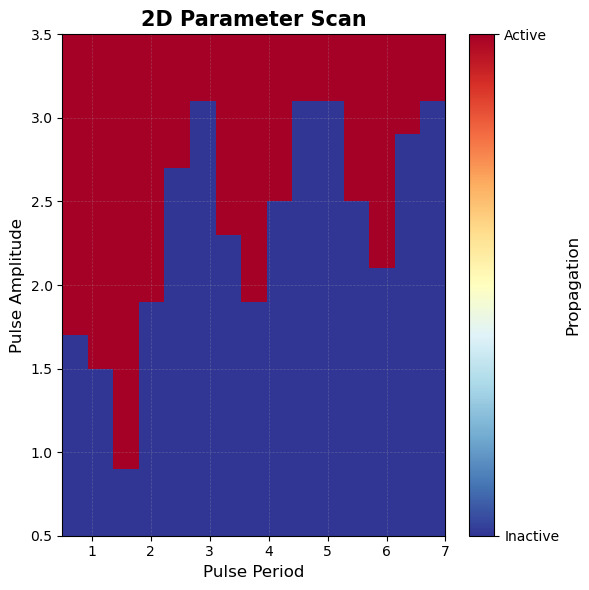

In [138]:
# Create bifurcation diagram
fig, ax = plt.subplots(figsize=(6, 6))

# Plot as heatmap
im = ax.imshow(
    bifurcation_matrix.T, 
    aspect='auto',
    origin='lower',
    extent=[pulse_per_range[0], pulse_per_range[-1],
            pulse_amp_range[0], pulse_amp_range[-1]],
    cmap='RdYlBu_r',
    interpolation='nearest'
)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Propagation', fontsize=12)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Inactive', 'Active'])

# Labels and title
ax.set_ylabel('Pulse Amplitude', fontsize=12)
ax.set_xlabel('Pulse Period', fontsize=12)
ax.set_title('2D Parameter Scan',
# \n(Analysis window: t = 100-150)', 
             fontsize=15, fontweight='bold')

# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

## Optional: Save data
# np.savez('bifurcation_data.npz', 
#          bifurcation_matrix=bifurcation_matrix,
#          pulse_amp_range=pulse_amp_range,
#          pulse_per_range=pulse_per_range)
# print("\nBifurcation data saved to 'bifurcation_data.npz'")


In [148]:
1/3.5, 1/6

(0.2857142857142857, 0.16666666666666666)

In [120]:
y_ini

array([ -1.89530054, -13.55833325,  -1.89530054, -13.55833325])

# Frequency Scan

In [128]:
# Bifurcation parameter set
steps = 50

par_min, par_max = 0.59, 0.63
# par_min, par_max = 4, 2

par_set = linspace(par_min, par_max, steps)

pulse_wid = 4.
# pulse_amp = 1 # supra at 1.0
pulse_per = 10

# Time array
time_stop = 200
time = linspace(start=0, stop=time_stop, num=time_stop*sr)

results_min_f      = dict()
results_min_inds_f = dict()
results_max_f      = dict()
results_max_inds_f = dict()

rows = time.size

peaks_all = list()

num = 'Ex'

# Simulation "forward"
for par in par_set:

    pert = h_ex_0 + par*ss.rect(mod(time, pulse_per)-(pulse_per)/2+pulse_wid/2, pulse_wid)
  
    solution = solve_ivp(fun=one_oscillator, t_span=(0, time_stop), y0=y_ini, t_eval=time,
              args=(h_in_0, pars, sr, time_stop, pert), 
              method='BDF', max_step=0.1)

    t, y_pert = solution.t, solution.y.T

    series = y_pert[2*rows//3 - int(pulse_wid*sr):, 0]
                
    if var(series) < 0.001:

        if num not in results_min_f:
            
            results_min_f['Ex']      = [series[-1]]
            results_min_inds_f['Ex'] = [0]    
           
        else:
            results_min_f['Ex'].append(series[-1])
            results_min_inds_f['Ex'].append(0)    

        if num not in results_max_f:
            
            results_max_f['Ex']      = [series[-1]]
            results_max_inds_f['Ex'] = [0]    
           
        else:
            results_max_f['Ex'].append(series[-1])
            results_max_inds_f['Ex'].append(0)    

    else:
        
        y_f_max_inds = find_peaks(series, distance=100)
        y_f_maxs     = series[y_f_max_inds[0]]

        y_f_min_inds = find_peaks(-series, distance=100)
        y_f_mins     = series[y_f_min_inds[0]]

        if num not in results_min_f:

            results_min_f[num]      = [y_f_mins]
            results_min_inds_f[num] = [y_f_min_inds]
            
            results_max_f[num]      = [y_f_maxs]
            results_max_inds_f[num] = [y_f_max_inds]

        else:

            results_min_f['Ex'].append(y_f_mins)
            results_min_inds_f['Ex'].append(y_f_min_inds)
            
            results_max_f['Ex'].append(y_f_maxs)
            results_max_inds_f['Ex'].append(y_f_max_inds)


    # if par != par_set[-1]:
        
    y_ini = y_pert[-1, :]
        
peaks_all = asarray(peaks_all)

print('')
print('Scan complete!', list(peaks_all.shape))
print('')


Scan complete! [0]



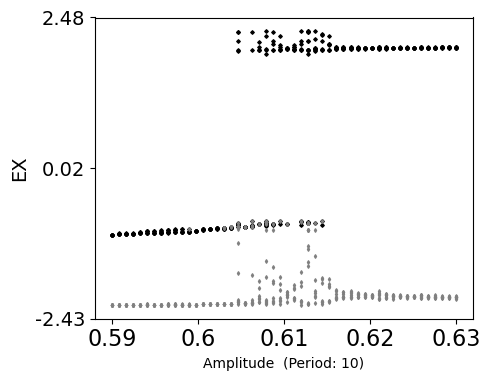

In [129]:
fig, ax = plot_bifdiagram(results_min_f, results_max_f, par_set)

ax.set_xlabel(f'Amplitude  (Period: {pulse_per})', fontsize=10);

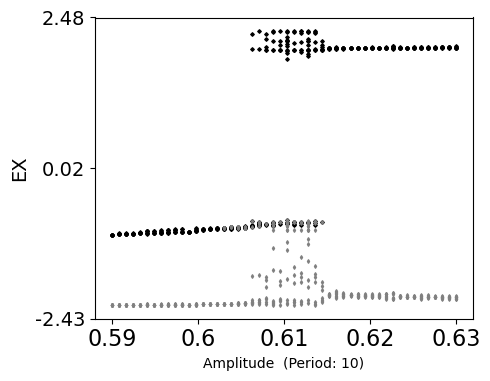

In [127]:
fig, ax = plot_bifdiagram(results_min_f, results_max_f, par_set)

ax.set_xlabel(f'Amplitude  (Period: {pulse_per})', fontsize=10);

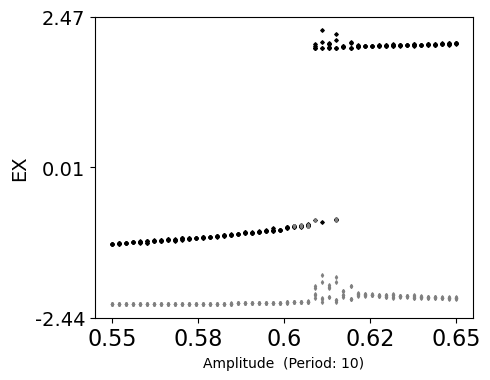

In [119]:
fig, ax = plot_bifdiagram(results_min_f, results_max_f, par_set)

ax.set_xlabel(f'Amplitude  (Period: {pulse_per})', fontsize=10);


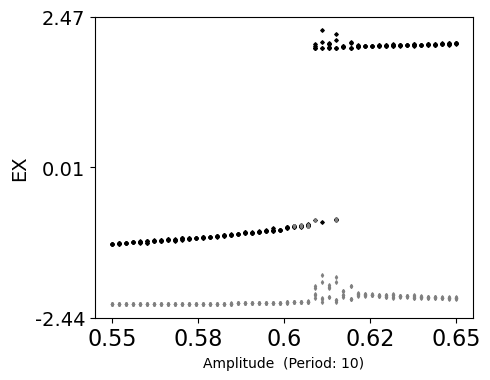

In [117]:
fig, ax = plot_bifdiagram(results_min_f, results_max_f, par_set)

ax.set_xlabel(f'Amplitude  (Period: {pulse_per})', fontsize=10);

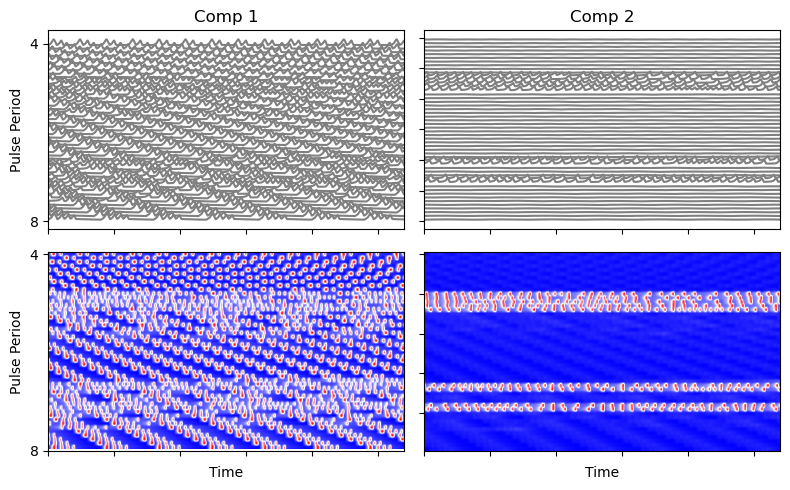

In [105]:
series_Ex1, series_Ex2 = series_all[:-1:2, :], series_all[1::2, :]

fig, ax = subplots(nrows=2, ncols=2, figsize=(8, 5))

ax[0, 0].plot  (series_Ex1.T - 3*arange(series_Ex1.shape[0]), color='gray');
ax[0, 0].set_title('Comp 1')
ax[0, 0].set_xticklabels([])
ax[0, 0].set_yticks([0, -150])
ax[0, 0].set_yticklabels([str(par_min), str(par_max)])
ax[0, 0].set_ylabel('Pulse Period')

ax[0, 1].plot  (series_Ex2.T - 3*arange(series_Ex1.shape[0]), color='gray');
ax[0, 1].set_title('Comp 2')
ax[0, 1].set_xticklabels([])
ax[0, 1].set_yticklabels([])

ax[1, 0].imshow(series_Ex1, aspect='auto', cmap='bwr');
ax[1, 0].set_xticklabels([])
ax[1, 0].set_yticks([0, 50])
ax[1, 0].set_yticklabels([str(par_min), str(par_max)])
ax[1, 0].set_xlabel('Time')
ax[1, 0].set_ylabel('Pulse Period')

ax[1, 1].imshow(series_Ex2, aspect='auto', cmap='bwr');
ax[1, 1].set_xticklabels([])
ax[1, 1].set_yticklabels([])
ax[1, 1].set_xlabel('Time')


ax[0, 0].margins(x=0)
ax[0, 1].margins(x=0)

fig.tight_layout()

# Bifurcation Diagram

In [68]:
# Bifurcation parameter set
steps = 30

par_min, par_max = -6.5, -6.8
# par_min, par_max = -6.8, -6.5

par_set = linspace(par_min, par_max, steps)

# Time array
time_stop = 500
time = linspace(start=0, stop=time_stop, num=time_stop*sr)

pert = h_ex_0 + pulse_amp*ss.rect(mod(time, pulse_per)-(pulse_per)/2+pulse_wid/2, pulse_wid)


results_min_f      = dict()
results_min_inds_f = dict()
results_max_f      = dict()
results_max_inds_f = dict()

rows = time.size

# pulse = []

# Simulation "forward"
for par in par_set:
      
    y_pert = odeint(func=oscillator, y0=y_ini, t=time, 
                  args=(par, h_in_0, pars, frac_E, frac_I, sr, time_stop, pert), 
                  hmax=0.1)

    for num, series in enumerate(y_pert[rows//2:,:-1:2].T):
                
        if var(series) < 0.0001:
    
            if num not in results_min_f:
                
                results_min_f[num]      = [series[-1]]
                results_min_inds_f[num] = [0]    
               
            else:
                results_min_f[num].append(series[-1])
                results_min_inds_f[num].append(0)    

            if num not in results_max_f:
                
                results_max_f[num]      = [series[-1]]
                results_max_inds_f[num] = [0]    
               
            else:
                results_max_f[num].append(series[-1])
                results_max_inds_f[num].append(0)    

        else:
            
            y_f_max_inds = find_peaks(series, distance=100)
            y_f_maxs     = series[y_f_max_inds[0]]

            y_f_min_inds = find_peaks(-series, distance=100)
            y_f_mins     = series[y_f_min_inds[0]]

            if num not in results_min_f:

                results_min_f[num]      = [y_f_mins]
                results_min_inds_f[num] = [y_f_min_inds]
                
                results_max_f[num]      = [y_f_maxs]
                results_max_inds_f[num] = [y_f_max_inds]

            else:

                results_min_f[num].append(y_f_mins)
                results_min_inds_f[num].append(y_f_min_inds)
                
                results_max_f[num].append(y_f_maxs)
                results_max_inds_f[num].append(y_f_max_inds)


    if par != par_set[-1]:
        
        y_ini = y_pert[-1, :]

print('')
print('Scan complete!', list(around(y_pert[-1,:],3)))
print('')


Scan complete! [np.float64(-1.664), np.float64(-13.491), np.float64(-1.591), np.float64(-13.422)]



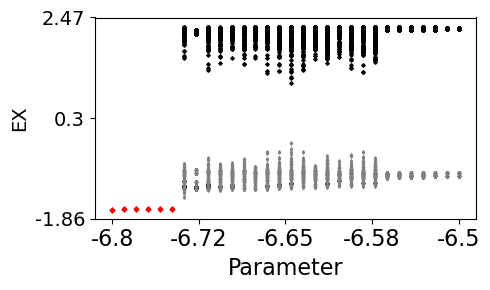

In [69]:
fig, ax = plot_bifdiagram(results_min_f, results_max_f, par_set)


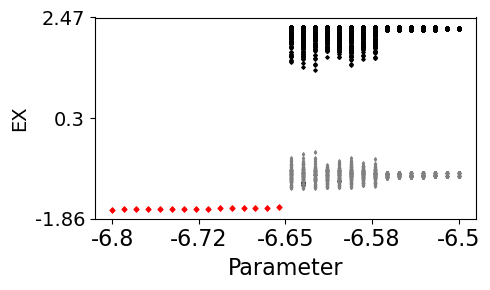

In [67]:
fig, ax = plot_bifdiagram(results_min_f, results_max_f, par_set)


# Distance Metrics

In [128]:
import numpy as np
from scipy.spatial.distance import euclidean

def path_length(trajectory):
    """Calculate the total path length of a trajectory"""
    displacements = np.linalg.norm(np.diff(trajectory, axis=0), axis=1)
    return np.sum(displacements)

def trajectory_difference_path_based(trajectory_data):
    """
    Compare trajectories based on their actual path characteristics
    """
    osc1_traj = trajectory_data[:, :2]
    osc2_traj = trajectory_data[:, 2:]
    
    # 1. Path length difference
    path1_length = path_length(osc1_traj)
    path2_length = path_length(osc2_traj)
    path_length_diff = abs(path1_length - path2_length)
    
    # 2. Area between paths (integrated distance)
    distances = np.linalg.norm(osc1_traj - osc2_traj, axis=1)
    area_between = np.trapz(distances, dx=1)
    
    # 3. Dynamic differences (velocity/orientation)
    vel1 = np.diff(osc1_traj, axis=0)
    vel2 = np.diff(osc2_traj, axis=0)
    
    # Cosine similarity of velocities (how aligned are movements)
    dot_products = np.sum(vel1 * vel2, axis=1)
    norms_product = np.linalg.norm(vel1, axis=1) * np.linalg.norm(vel2, axis=1)
    cosine_similarities = dot_products / (norms_product + 1e-10)  # avoid division by zero
    avg_alignment = np.mean(cosine_similarities)
    
    return {
        'path_length_difference': path_length_diff,
        'area_between_paths': area_between,
        'velocity_alignment': avg_alignment,
        'composite_measure': path_length_diff + area_between + (1 - avg_alignment)
    }

def dtw_distance(a, b):
    """Simple DTW implementation"""
    n, m = len(a), len(b)
    dtw_matrix = np.zeros((n+1, m+1))
    dtw_matrix[0, 1:] = np.inf
    dtw_matrix[1:, 0] = np.inf
    
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j],    # insertion
                                         dtw_matrix[i, j-1],    # deletion  
                                         dtw_matrix[i-1, j-1])  # match
    
    return dtw_matrix[n, m]

def trajectory_difference_dtw(trajectory_data):
    """
    Use DTW to handle trajectories that are similar but phase-shifted
    """
    osc1_traj = trajectory_data[:, :2]
    osc2_traj = trajectory_data[:, 2:]
    
    # Apply DTW to each dimension separately
    dtw_x = dtw_distance(osc1_traj[:, 0], osc2_traj[:, 0])
    dtw_y = dtw_distance(osc1_traj[:, 1], osc2_traj[:, 1])
    
    # Combined DTW distance
    combined_dtw = np.sqrt(dtw_x**2 + dtw_y**2)
    
    return combined_dtw

def trajectory_shape_difference(trajectory_data):
    """
    Compare the shape characteristics of trajectories
    """
    osc1_traj = trajectory_data[:, :2]
    osc2_traj = trajectory_data[:, 2:]
    
    # Calculate curvature for each trajectory
    def calculate_curvature(traj):
        dx_dt = np.gradient(traj[:, 0])
        dy_dt = np.gradient(traj[:, 1])
        d2x_dt2 = np.gradient(dx_dt)
        d2y_dt2 = np.gradient(dy_dt)
        
        curvature = np.abs(dx_dt * d2y_dt2 - dy_dt * d2x_dt2) / (dx_dt**2 + dy_dt**2 + 1e-10)**1.5
        return curvature
    
    curvature1 = calculate_curvature(osc1_traj)
    curvature2 = calculate_curvature(osc2_traj)
    
    # Compare curvature profiles
    curvature_diff = np.mean(np.abs(curvature1 - curvature2))
    
    # Compare turning points (local maxima in curvature)
    from scipy.signal import find_peaks
    peaks1, _ = find_peaks(curvature1, height=np.mean(curvature1))
    peaks2, _ = find_peaks(curvature2, height=np.mean(curvature2))
    
    turning_point_diff = abs(len(peaks1) - len(peaks2))
    
    return curvature_diff + turning_point_diff

def comprehensive_trajectory_analysis(trajectory_data):
    """
    Comprehensive analysis that should distinguish different path types
    """
    osc1_traj = trajectory_data[:, :2]
    osc2_traj = trajectory_data[:, 2:]
    
    results = {}
    
    # Basic point-wise distances (your original approach)
    point_distances = np.linalg.norm(osc1_traj - osc2_traj, axis=1)
    results['max_point_distance'] = np.max(point_distances)
    results['mean_point_distance'] = np.mean(point_distances)
    results['area_between'] = np.trapezoid(point_distances, dx=1)
    
    # Path-based measures
    results['path_length_osc1'] = path_length(osc1_traj)
    results['path_length_osc2'] = path_length(osc2_traj)
    results['path_length_difference'] = abs(results['path_length_osc1'] - results['path_length_osc2'])
    
    # Dynamic measures
    vel1 = np.diff(osc1_traj, axis=0)
    vel2 = np.diff(osc2_traj, axis=0)
    
    velocity_correlations = []
    for i in range(len(vel1)):
        if np.linalg.norm(vel1[i]) > 0 and np.linalg.norm(vel2[i]) > 0:
            cos_sim = np.dot(vel1[i], vel2[i]) / (np.linalg.norm(vel1[i]) * np.linalg.norm(vel2[i]))
            velocity_correlations.append(cos_sim)
    
    results['velocity_correlation'] = np.mean(velocity_correlations) if velocity_correlations else 0
    
    # Shape-based measure
    results['shape_difference'] = trajectory_shape_difference(trajectory_data)
    
    # Create a single composite score
    results['composite_score'] = (
        results['area_between'] + 
        results['path_length_difference'] + 
        (1 - results['velocity_correlation']) +
        results['shape_difference']
    )
    
    return results


result_similar = comprehensive_trajectory_analysis(y_similar[105000:120000, :])

result_different = comprehensive_trajectory_analysis(y_different[105000:120000, :])

result_medium = comprehensive_trajectory_analysis(y_medium[105000:120000, :])

print("Similar trajectories:", result_similar['composite_score'])
print("Different trajectories:", result_different['composite_score'])
print("Medium trajectories:", result_medium['composite_score'])


Similar trajectories: 8624.300107775958
Different trajectories: 24771.765353695973
Medium trajectories: 54975.10050609993


In [118]:
result_similar

{'max_point_distance': np.float64(5.289331091709366),
 'mean_point_distance': np.float64(0.5749351955355837),
 'area_between': np.float64(8622.315682854667),
 'path_length_osc1': np.float64(36.908308037977434),
 'path_length_osc2': np.float64(35.12698331057021),
 'path_length_difference': np.float64(1.781324727407224),
 'velocity_correlation': np.float64(0.9730216308729599),
 'shape_difference': np.float64(0.17612182475539645),
 'composite_score': np.float64(8624.300107775958)}

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def extract_measures(trajectory_data):
    """
    Extract the three measures from a trajectory
    """
    # Reuse the functions from our previous analysis
    results = comprehensive_trajectory_analysis(trajectory_data)
    
    max_dist = results['max_point_distance']
    path_diff = results['path_length_difference']
    shape_diff = results['shape_difference']
    
    return [max_dist, path_diff, shape_diff]

# Alternative: Individual functions if you want them separate
def max_point_distance(trajectory_data):
    osc1_traj = trajectory_data[:, :2]
    osc2_traj = trajectory_data[:, 2:]
    distances = np.linalg.norm(osc1_traj - osc2_traj, axis=1)
    return np.max(distances)

def path_length_difference(trajectory_data):
    osc1_traj = trajectory_data[:, :2]
    osc2_traj = trajectory_data[:, 2:]
    
    def path_length(traj):
        displacements = np.linalg.norm(np.diff(traj, axis=0), axis=1)
        return np.sum(displacements)
    
    path1 = path_length(osc1_traj)
    path2 = path_length(osc2_traj)
    return abs(path1 - path2)

def shape_difference(trajectory_data):
    osc1_traj = trajectory_data[:, :2]
    osc2_traj = trajectory_data[:, 2:]
    
    def calculate_curvature(traj):
        dx_dt = np.gradient(traj[:, 0])
        dy_dt = np.gradient(traj[:, 1])
        d2x_dt2 = np.gradient(dx_dt)
        d2y_dt2 = np.gradient(dy_dt)
        
        curvature = np.abs(dx_dt * d2y_dt2 - dy_dt * d2x_dt2) / (dx_dt**2 + dy_dt**2 + 1e-10)**1.5
        return curvature
    
    curvature1 = calculate_curvature(osc1_traj)
    curvature2 = calculate_curvature(osc2_traj)
    
    from scipy.signal import find_peaks
    peaks1, _ = find_peaks(curvature1, height=np.mean(curvature1))
    peaks2, _ = find_peaks(curvature2, height=np.mean(curvature2))
    
    curvature_diff = np.mean(np.abs(curvature1 - curvature2))
    turning_point_diff = abs(len(peaks1) - len(peaks2))
    
    return curvature_diff + turning_point_diff

def plot_3d_trajectory_clusters(trajectories, labels=None, colors=None):
    """
    Create a 3D scatter plot of trajectory measures
    
    Parameters:
    trajectories: list of numpy arrays, each shape (samples, 4)
    labels: optional list of labels for each trajectory
    colors: optional list of colors for each trajectory
    """
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # If no colors provided, use a colormap
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(trajectories)))
    elif len(colors) != len(trajectories):
        colors = [colors[0]] * len(trajectories)  # Use first color for all
    
    # Collect all measures for axis limits
    all_measures = []
    
    for index, trajectory in enumerate(trajectories):
        # Calculate the three measures
        measures = [
            max_point_distance(trajectory),
            path_length_difference(trajectory), 
            shape_difference(trajectory)
        ]
        
        all_measures.append(measures)
        
        # Create label
        if labels is not None and index < len(labels):
            label = labels[index]
        else:
            label = f'Traj {index+1}'
        
        # Plot the point
        ax.scatter(*measures, 
                  c=[colors[index]], 
                  s=100, 
                  label=label,
                  alpha=0.7,
                  edgecolors='w',
                  linewidth=0.5)
    
    all_measures = np.array(all_measures)
    
    # Set labels and title
    ax.set_xlabel('Max Point Distance', fontsize=12, labelpad=10)
    ax.set_ylabel('Path Length Difference', fontsize=12, labelpad=10)
    ax.set_zlabel('Shape Difference', fontsize=12, labelpad=10)
    ax.set_title('3D Trajectory Clustering', fontsize=14, fontweight='bold', pad=20)
    
    # Add legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Adjust viewing angle for better visualization
    ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    plt.show()
    
    return all_measures

# Enhanced version with clustering visualization
def plot_3d_trajectory_clusters_enhanced(trajectories, group_labels=None, cluster_colors=None):
    """
    Enhanced version with better grouping and visualization
    """
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Define colors for different groups
    if cluster_colors is None:
        cluster_colors = plt.cm.Set1(np.linspace(0, 1, len(set(group_labels)) if group_labels else 1))
    
    all_measures = []
    
    for index, trajectory in enumerate(trajectories):
        measures = [
            max_point_distance(trajectory),
            path_length_difference(trajectory), 
            shape_difference(trajectory)
        ]
        all_measures.append(measures)
        
        # Determine color and label based on grouping
        if group_labels and index < len(group_labels):
            group_idx = group_labels[index]
            color = cluster_colors[group_idx]
            label = f'Group {group_idx}' if index == 0 or group_labels[index-1] != group_idx else ""
        else:
            color = 'blue'
            label = f'Traj {index+1}'
        
        ax.scatter(*measures, 
                  c=[color], 
                  s=100, 
                  label=label,
                  alpha=0.7,
                  edgecolors='w',
                  linewidth=1)
    
    all_measures = np.array(all_measures)
    
    # Set labels with units if known
    ax.set_xlabel('Max Distance\n(larger = more separation)', fontsize=11, labelpad=10)
    ax.set_ylabel('Path Length Diff\n(larger = different path lengths)', fontsize=11, labelpad=10)
    ax.set_zlabel('Shape Difference\n(larger = different shapes)', fontsize=11, labelpad=10)
    ax.set_title('3D Trajectory Measure Space\n(Cluster Analysis)', fontsize=14, fontweight='bold', pad=20)
    
    # Add grid and improve layout
    ax.grid(True, alpha=0.3)
    
    # Remove duplicate labels in legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), 
              bbox_to_anchor=(1.15, 1), loc='upper left')
    
    # Multiple viewing angles
    print("Plotting from multiple angles...")
    angles = [(30, 45), (20, 135), (10, 225)]
    
    for i, (elev, azim) in enumerate(angles):
        ax.view_init(elev=elev, azim=azim)
        plt.draw()
        plt.pause(0.5)  # Brief pause to see different angles
    
    plt.tight_layout()
    plt.show()
    
    return all_measures

# Simple version following your pseudocode exactly
def simple_3d_plot(trajectory):
    """
    Simple version following your pseudocode exactly
    """
 
    for index, trajectory in enumerate(trajectories):
        measures = [
            max_point_distance(trajectory),
            path_length_difference(trajectory), 
            max_point_distance(trajectory)
        ]
        
        ax.scatter(*measures, s=80, alpha=0.7, label=f'Traj {index+1}')
    
    ax.set_xlabel('Max Point Distance')
    ax.set_ylabel('Path Length Difference')
    ax.set_zlabel('Shape Difference')
    ax.set_title('3D Trajectory Measures')
    ax.legend()
    
    plt.show()


# 3D Scatter of trajectories measures

In [8]:
# pulse_wid = 4.
# pulse_per = 200.

# # Time array
# time_stop = 200
# sr        = 1000
# time      = linspace(start=0, stop=time_stop, num=time_stop*sr)

# rows = time.size

# fig = plt.figure(figsize=(6, 6))

# ax = fig.add_subplot(projection='3d')

# pulse_amps = linspace(1, 8, 30)


# measures_all = list()

# for pulse_amp in pulse_amps:
    
#     pert = h_ex_0 + pulse_amp*ss.rect(mod(time, pulse_per)-(pulse_per)/2+pulse_wid/2, pulse_wid)

#     # Simulation
#     y_pert = odeint(func=oscillator, y0=y_ini, t=time, 
#                   args=(N, h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop, pert), 
#                   hmax=0.1)

#     trajectory = y_pert[105000:130000, :]
    
#     measures = [max_point_distance(trajectory), path_length_difference(trajectory), shape_difference(trajectory)]

#     measures_all.append(measures)


# param_min, param_max = np.min(pulse_amps), np.max(pulse_amps)
# param_norm = (pulse_amps - param_min) / (param_max - param_min)

# colormap = plt.get_cmap('spring')

# for ind, meas in enumerate(measures_all):
    
#     color = colormap(param_norm[ind])

#     scatter = ax.scatter(*meas, s=80, alpha=0.7, color=color)

# # Create colorbar with the correct colormap
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=colormap, 
#                                         norm=plt.Normalize(param_min, param_max)), 
#                    ax=ax, shrink=0.4, aspect=20, pad=0.1)
# cbar.set_label('Pulse Amplitude')


# ax.set_xlabel('Max Point Distance')
# ax.set_ylabel('Path Length Difference')
# ax.set_zlabel('Shape Difference')
# ax.set_title('3D Trajectory Measures')


# ax.view_init(50, 30)


In [9]:
# fig = plt.figure(figsize=(6, 6))

# ax = fig.add_subplot(projection='3d')

# for ind, meas in enumerate(measures_all):
    
#     color = colormap(param_norm[ind])

#     scatter = ax.scatter(*meas, s=80, alpha=0.7, color=color)

# # Create colorbar with the correct colormap
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=colormap, 
#                                         norm=plt.Normalize(param_min, param_max)), 
#                    ax=ax, shrink=0.4, aspect=20, pad=0.1)
# cbar.set_label('Pulse Amplitude')


# ax.set_xlabel('Max Point Distance')
# ax.set_ylabel('Path Length Difference')
# ax.set_zlabel('Shape Difference')
# ax.set_title('3D Trajectory Measures')

# ax.view_init(20, 30)

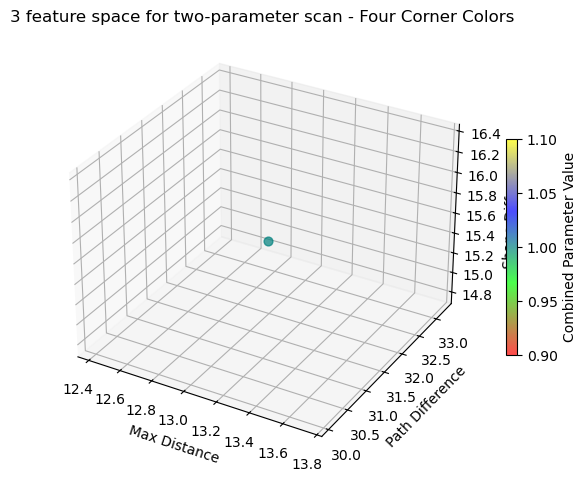

In [11]:
from matplotlib.colors import LinearSegmentedColormap

def create_2d_colormap():
    """Create a colormap that interpolates between four corners"""
    colors = [
        [1, 0, 0],  # Red - bottom-left
        [0, 1, 0],  # Green - bottom-right
        [0, 0, 1],  # Blue - top-left  
        [1, 1, 0],  # Yellow - top-right
    ]
    return LinearSegmentedColormap.from_list('four_corners', colors, N=256)



pulse_per = 200.

# Time array
time_stop = 200
sr        = 1000
time      = linspace(start=0, stop=time_stop, num=time_stop*sr)

rows = time.size


pulse_amps = linspace(2, 5, 40)
pulse_wids = linspace(2, 5, 40)


measures_all    = list()
combined_params = list()  # Store combined parameter values for coloring
color_values    = list()
osc_2_amps      = list()

for pulse_wid, pulse_amp in product(pulse_wids, pulse_amps):

    pert = h_ex_0 + pulse_amp*ss.rect(mod(time, pulse_per)-(pulse_per)/2+pulse_wid/2, pulse_wid)

    # Simulation
    y_pert = odeint(func=oscillator, y0=y_ini, t=time, 
                  args=(h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop, pert), 
                  hmax=0.1)

    trajectory = y_pert[100000:130000, :]

    osc_2_extr = trajectory[:, 2].max() - trajectory[:, 2].min()
    osc_2_amps.append(osc_2_extr)
    
    measures = [max_point_distance(trajectory), path_length_difference(trajectory), shape_difference(trajectory)]

    measures_all.   append(measures)
    combined_params.append(pulse_wid * pulse_amp) 

    # Create a combined value that captures both dimensions
    wid_norm = (pulse_wid - pulse_wids.min()) / (pulse_wids.max() - pulse_wids.min())
    amp_norm = (pulse_amp - pulse_amps.min()) / (pulse_amps.max() - pulse_amps.min())
    
    # This formula gives a smooth gradient across the 2D space
    combined_value = (wid_norm + amp_norm) / 2  # or try other combinations
    color_values.append(combined_value)


measures_array = np.array(measures_all)
# combined_params = np.array(combined_params)
color_values   = np.array(color_values)

mask = asarray(osc_2_amps) > 1

#################
# Plot
fig = plt.figure(figsize=(7, 7))
ax  = fig.add_subplot(111, projection='3d')

custom_cmap = create_2d_colormap()

scatter = ax.scatter(measures_array[mask, 0], measures_array[mask, 1], measures_array[mask, 2],
                    c=color_values[mask], cmap=custom_cmap, s=40, alpha=0.7)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.4)
cbar.set_label('Combined Parameter Value')

ax.set_xlabel('Max Distance')
ax.set_ylabel('Path Difference') 
ax.set_zlabel('Shape Difference')
ax.set_title('3 feature space for two-parameter scan - Four Corner Colors');


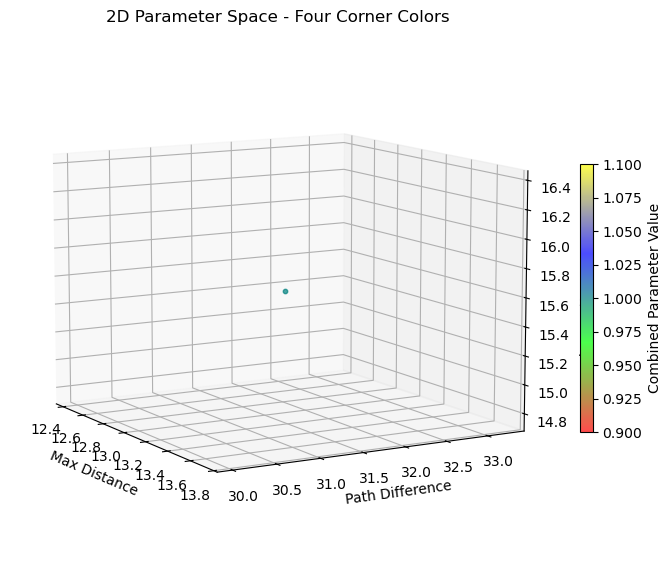

In [12]:
fig = plt.figure(figsize=(7, 7))
ax  = fig.add_subplot(111, projection='3d')

custom_cmap = create_2d_colormap()

mask = asarray(osc_2_amps) > 2

scatter = ax.scatter(measures_array[mask, 0], measures_array[mask, 1], measures_array[mask, 2],
                        c=asarray(color_values)[mask], cmap=custom_cmap, s=10, alpha=0.7)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.4)
cbar.set_label('Combined Parameter Value')


ax.set_xlabel('Max Distance')
ax.set_ylabel('Path Difference') 
ax.set_zlabel('Shape Difference')
ax.set_title('2D Parameter Space - Four Corner Colors')

ax.view_init(10, -30)

fig.tight_layout()


# Plotly Version

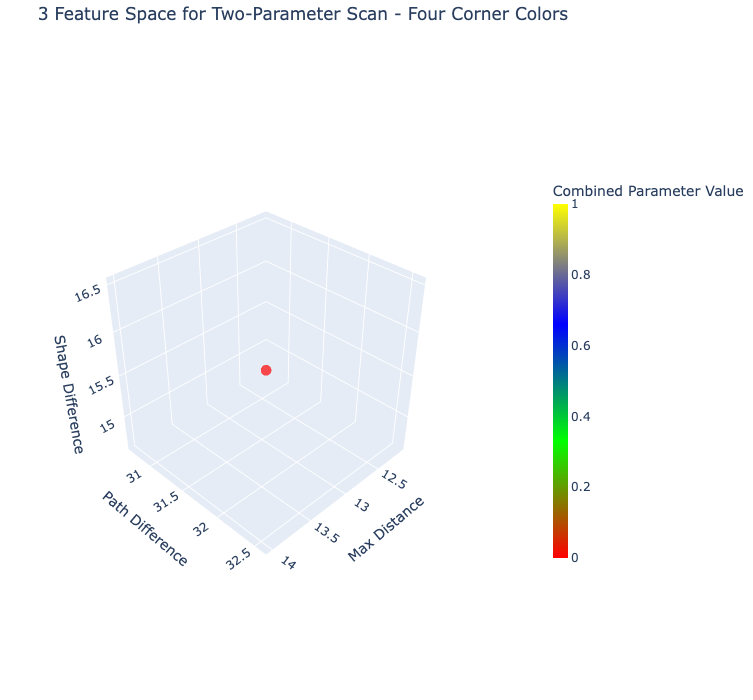

In [15]:
import plotly.graph_objects as go
import plotly.express as px
import numpy as np

# Convert your matplotlib colormap to Plotly
def create_plotly_colorscale(cmap_name='spring', n_colors=256):
    """Convert matplotlib colormap to Plotly colorscale"""
    cmap = plt.get_cmap(cmap_name)
    colorscale = []
    for i in range(n_colors):
        ratio = i / (n_colors - 1)
        rgb = cmap(ratio)
        colorscale.append([ratio, f'rgb({rgb[0]*255:.0f}, {rgb[1]*255:.0f}, {rgb[2]*255:.0f})'])
    return colorscale

# Create custom four-corner colorscale for Plotly
def create_four_corner_colorscale():
    """Create the same four-corner colorscale in Plotly"""
    return [
        [0.0, 'rgb(255, 0, 0)'],    # Red
        [0.33, 'rgb(0, 255, 0)'],   # Green
        [0.66, 'rgb(0, 0, 255)'],   # Blue
        [1.0, 'rgb(255, 255, 0)']   # Yellow
    ]

# Create the interactive Plotly figure
fig = go.Figure(data=[go.Scatter3d(
    x=measures_array[mask, 0],      # Max Distance
    y=measures_array[mask, 1],      # Path Difference
    z=measures_array[mask, 2],      # Shape Difference
    mode='markers',
    marker=dict(
        size=6,
        color=color_values,      # Combined Parameter Value
        colorscale=create_four_corner_colorscale(),  # Your custom colormap
        opacity=0.7,
        colorbar=dict(
            title='Combined Parameter Value',
            thickness=15,
            len=0.6
        )
    ),
    hovertemplate=(
        "<b>Max Distance:</b> %{x:.3f}<br>" +
        "<b>Path Difference:</b> %{y:.3f}<br>" +
        "<b>Shape Difference:</b> %{z:.3f}<br>" +
        "<b>Param Value:</b> %{marker.color:.3f}<br>" +
        "<extra></extra>"
    )
)])

# Update layout for better appearance
fig.update_layout(
    title='3 Feature Space for Two-Parameter Scan - Four Corner Colors',
    scene=dict(
        xaxis_title='Max Distance',
        yaxis_title='Path Difference',
        zaxis_title='Shape Difference',
        camera=dict(
            eye=dict(x=2.2, y=2.2, z=2.2)  # Initial camera position
        )
    ),
    width=700,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

# Pulse Parameter Scan 2D

COMPLETE
 


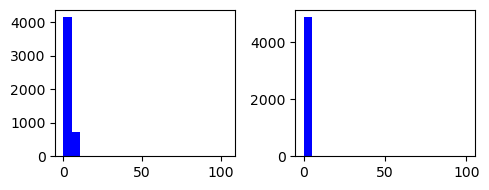

In [14]:
# Initial conditions y_last
y_last = y_ini.copy()

time_stop_pert = 200
sr             = 1000
time           = linspace(start=0, stop=time_stop_pert, num=time_stop_pert*sr)

resolution = 70

pulse_width_min, pulse_width_max = 0.1, 5.1
pulse_ampli_min, pulse_ampli_max = 5, 0.0001

pulse_width = linspace(pulse_width_min, pulse_width_max, resolution)
pulse_ampli = linspace(pulse_ampli_min, pulse_ampli_max, resolution)

pulse_period = 200

results_pert = list()

for pulse_wid, pulse_amp in product(pulse_width, pulse_ampli):

    h_ex_p = h_ex_0 + pulse_amp*ss.rect(mod(time, pulse_period)-pulse_period/2+pulse_wid/2, pulse_wid)

    y = odeint(func=oscillator, y0=y_last, t=time, args=(h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop_pert, h_ex_p),
              hmax=0.1)


    results_pert.append((sum(y[time_stop_pert*sr//2:, 0] - y_last[0])/sr, 
                         sum(y[time_stop_pert*sr//2:, 2] - y_last[2])/sr
                     ))

results_pert_ex1_matrix = asarray(results_pert)[:, 0].reshape(resolution, resolution)
results_pert_ex2_matrix = asarray(results_pert)[:, 1].reshape(resolution, resolution)

print('COMPLETE')
print(' ')

fig, ax = subplots(ncols=2, figsize=(5, 2))

ax[0].hist(results_pert_ex1_matrix.ravel(), bins=20, color='b');

ax[1].hist(results_pert_ex2_matrix.ravel(), bins=20, color='b');

fig.tight_layout()


'PulsePert_Homoclinic_frac_E=0.15_frac_I=0.0.png'

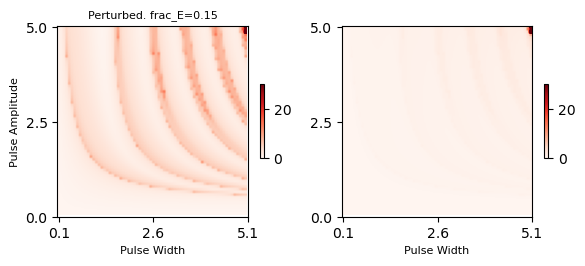

In [16]:
vmin1, vmax1 = 0, 30
vmin2, vmax2 = 0, 30

fig, ax = subplots(figsize=(6, 4), ncols=2)

im1 = ax[0].imshow(results_pert_ex1_matrix.T, cmap='Reds', vmin=vmin1, vmax=vmax1)

ax[0].set_xlabel('Pulse Width', fontsize=8)
ax[0].set_ylabel('Pulse Amplitude', fontsize=8)
ax[0].set_xticks(linspace(0, resolution, 3))
ax[0].set_xticklabels(around(linspace(pulse_width_min, pulse_width_max, 3),1))
ax[0].set_yticks(linspace(0, resolution, 3))
ax[0].set_yticklabels(around(linspace(pulse_ampli_min, pulse_ampli_max, 3), 2))
ax[0].set_title(f'Perturbed. frac_E={frac_E}', fontsize=8)



im2 = ax[1].imshow(results_pert_ex2_matrix.T, cmap='Reds', vmin=vmin2, vmax=vmax2)

ax[1].set_xlabel('Pulse Width', fontsize=8)
# ax[1].set_ylabel('Pulse Amplitude', fontsize=8)
ax[1].set_xticks(linspace(0, resolution, 3))
ax[1].set_xticklabels(around(linspace(pulse_width_min, pulse_width_max, 3), 1))
ax[1].set_yticks(linspace(0, resolution, 3))
ax[1].set_yticklabels(around(linspace(pulse_ampli_min, pulse_ampli_max, 3), 2))


fig.colorbar(im1, ax=ax[0], shrink=0.2);
fig.colorbar(im2, ax=ax[1], shrink=0.2);

fig.tight_layout()

if pars[1] == 1.5:
    
    title_chars = 'Figs/N=1/Fig_2Cb_PulsePert_SNIC.png'
    
elif pars[1] == 2.5:

    title_chars = 'PulsePert_Homoclinic_frac_E=' + str(frac_E) + '_frac_I=' + str(frac_I) +'.png'

# fig.savefig(title_chars, dpi=300, format='png', bbox_inches='tight')

title_chars

In [9]:
h_ex_0

-6.95